<a href="https://colab.research.google.com/github/Sia0412/Flask-Mega/blob/main/IOT_ecosystem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#@title dataset shape
import pandas as pd
import numpy as np
df = pd.read_csv("/content/sample_data/digital_ecosystem_smart_healthcare_dataset.csv")
print("Dataset Shape:", df.shape)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset Shape: (4000, 18)
Rows: 4000
Columns: 18


In [ ]:
#@title column names
print(df.columns.tolist())

['Heart_Rate', 'Blood_Pressure', 'Blood_Oxygen_Level', 'Body_Temperature', 'Respiration_Rate', 'Glucose_Level', 'ECG_Signal_Intensity', 'Activity_Level', 'Sleep_Duration_Hours', 'Stress_Index', 'IoT_Device_Connectivity', 'EHR_Data_Completeness', 'Wearable_Device_Count', 'Daily_Steps', 'Healthcare_Network_Latency_ms', 'Cloud_Data_Transfer_Rate', 'Medical_Alert_Frequency', 'Patient_Health_Status']


In [ ]:
#@title data types
df.dtypes

,0
Heart_Rate,int64
Blood_Pressure,int64
Blood_Oxygen_Level,float64
Body_Temperature,float64
Respiration_Rate,int64
Glucose_Level,int64
ECG_Signal_Intensity,float64
Activity_Level,int64
Sleep_Duration_Hours,float64
Stress_Index,int64


In [ ]:
#@title missing values
missing_df = pd.DataFrame({
    "Column": df.columns,
    "Missing Values": df.isnull().sum().values
})

missing_df

,Column,Missing Values
0,Heart_Rate,0
1,Blood_Pressure,0
2,Blood_Oxygen_Level,0
3,Body_Temperature,0
4,Respiration_Rate,0
5,Glucose_Level,0
6,ECG_Signal_Intensity,0
7,Activity_Level,0
8,Sleep_Duration_Hours,0
9,Stress_Index,0


In [ ]:
#@title finding duplicate rows
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [ ]:
#@title descriptive statistics
display(df.describe().T)


,count,mean,std,min,25%,50%,75%,max
Heart_Rate,4000.0,80.615250,27.307245,45.00,57.00000,78.000,99.00000,180.00
Blood_Pressure,4000.0,134.757000,47.428096,80.00,80.00000,131.000,184.00000,200.00
Blood_Oxygen_Level,4000.0,95.546110,4.579600,85.00,92.42750,96.740,100.00000,100.00
Body_Temperature,4000.0,36.520075,2.042645,34.00,34.74750,36.255,37.88000,41.00
Respiration_Rate,4000.0,18.101500,7.249161,8.00,12.00000,18.000,23.00000,40.00
Glucose_Level,4000.0,102.600750,41.788760,60.00,63.00000,93.000,127.00000,300.00
ECG_Signal_Intensity,4000.0,2.503020,1.437716,0.50,1.24475,2.413,3.63125,5.00
Activity_Level,4000.0,49.366750,33.483041,0.00,20.00000,50.000,77.00000,100.00
Sleep_Duration_Hours,4000.0,6.973878,2.825316,2.00,4.81750,6.980,9.08000,12.00
Stress_Index,4000.0,50.171250,34.237428,0.00,20.00000,50.000,80.00000,100.00


In [ ]:
#@title target distribution
target = "Patient_Health_Status"

display(df[target].value_counts())

display(round(df[target].value_counts(normalize=True)*100,2))


,count
Patient_Health_Status,
Critical,1003
Moderate_Risk,1001
Stable,999
High_Risk,997


,proportion
Patient_Health_Status,
Critical,25.07
Moderate_Risk,25.02
Stable,24.98
High_Risk,24.92


In [ ]:
#@title Feature Ranges
numeric_cols = df.select_dtypes(include=np.number).columns

ranges = pd.DataFrame({
    "Minimum": df[numeric_cols].min(),
    "Maximum": df[numeric_cols].max(),
    "Range": df[numeric_cols].max()-df[numeric_cols].min()
})

display(ranges)

,Minimum,Maximum,Range
Heart_Rate,45.00,180.00,135.00
Blood_Pressure,80.00,200.00,120.00
Blood_Oxygen_Level,85.00,100.00,15.00
Body_Temperature,34.00,41.00,7.00
Respiration_Rate,8.00,40.00,32.00
Glucose_Level,60.00,300.00,240.00
ECG_Signal_Intensity,0.50,5.00,4.50
Activity_Level,0.00,100.00,100.00
Sleep_Duration_Hours,2.00,12.00,10.00
Stress_Index,0.00,100.00,100.00


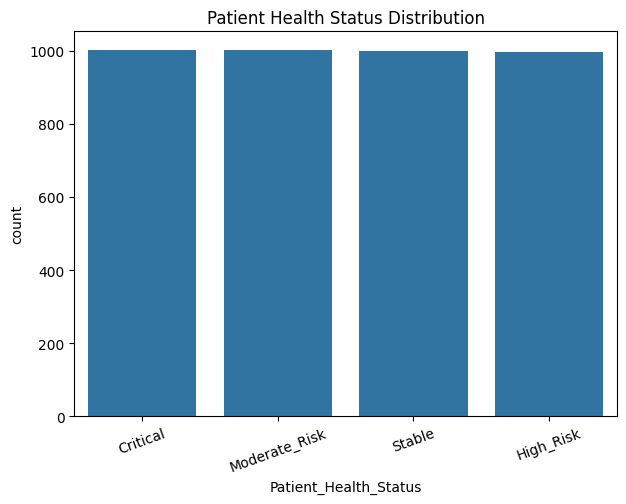

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Patient_Health_Status",
    order=df["Patient_Health_Status"].value_counts().index
)

plt.title("Patient Health Status Distribution")
plt.xticks(rotation=20)
plt.show()

In [ ]:
#@title check target column (step-2)
target = "Patient_Health_Status"

if target in df.columns:
    print("Target column exists.")
else:
    print("Target column NOT found.")

Target column exists.


In [ ]:
#@title class counts and percentage
print(df[target].value_counts())
print(round(df[target].value_counts(normalize=True)*100,2))

Patient_Health_Status
Critical         1003
Moderate_Risk    1001
Stable            999
High_Risk         997
Name: count, dtype: int64
Patient_Health_Status
Critical         25.07
Moderate_Risk    25.02
Stable           24.98
High_Risk        24.92
Name: proportion, dtype: float64


In [ ]:
#@title Encode target labels
label_mapping = {
    "Stable": 0,
    "Moderate_Risk": 1,
    "High_Risk": 2,
    "Critical": 3
}

# Keep original labels for later interpretation
df["Patient_Health_Status_Label"] = df[target]

# Encode target
df[target] = df[target].map(label_mapping)

display(df[["Patient_Health_Status_Label",
            "Patient_Health_Status"]].head())

,Patient_Health_Status_Label,Patient_Health_Status
0,Stable,0
1,High_Risk,2
2,Stable,0
3,Moderate_Risk,1
4,Moderate_Risk,1


In [ ]:
print(df[target].value_counts().sort_index())


Patient_Health_Status
0     999
1    1001
2     997
3    1003
Name: count, dtype: int64


In [ ]:
#@title Prepare feature matrix and target vector
X = df.drop(columns=[
    "Patient_Health_Status",
    "Patient_Health_Status_Label"
])

y = df["Patient_Health_Status"]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (4000, 17)
Target Shape: (4000,)


In [ ]:
#@title step 3 (verify target column)
# Target column names

target = "Patient_Health_Status"
original_target = "Patient_Health_Status_Label"

print("Encoded Target Exists:",
      target in df.columns)

print("Original Target Exists:",
      original_target in df.columns)

Encoded Target Exists: True
Original Target Exists: True


In [ ]:
print("Checking Feature Matrix...\n")

if target in X.columns:
    print("ERROR: Target column is inside X.")
else:
    print("PASS: Target column removed from X.")

if original_target in X.columns:
    print("ERROR: Original labels are inside X.")
else:
    print("PASS: Original labels removed from X.")

Checking Feature Matrix...

PASS: Target column removed from X.
PASS: Original labels removed from X.


In [ ]:
#@title input feature checking
print("Input Features Used")

for i, feature in enumerate(X.columns, start=1):
    print(f"{i}. {feature}")

Input Features Used
1. Heart_Rate
2. Blood_Pressure
3. Blood_Oxygen_Level
4. Body_Temperature
5. Respiration_Rate
6. Glucose_Level
7. ECG_Signal_Intensity
8. Activity_Level
9. Sleep_Duration_Hours
10. Stress_Index
11. IoT_Device_Connectivity
12. EHR_Data_Completeness
13. Wearable_Device_Count
14. Daily_Steps
15. Healthcare_Network_Latency_ms
16. Cloud_Data_Transfer_Rate
17. Medical_Alert_Frequency


In [ ]:
#@title check for suspicions
keywords = [
    "health_status",
    "target",
    "risk",
    "label",
    "class"
]

suspected = []

for column in X.columns:

    column_lower = column.lower()

    for word in keywords:

        if word in column_lower:
            suspected.append(column)
            break

if len(suspected)==0:
    print("No suspicious feature names found.")
else:
    print("Possible leakage features:")

    for feature in suspected:
        print(feature)

No suspicious feature names found.


In [ ]:
print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

print()

if len(X)==len(y):
    print("PASS: X and y have the same number of samples.")
else:
    print("ERROR: Sample mismatch.")

Feature Matrix Shape : (4000, 17)
Target Shape : (4000,)

PASS: X and y have the same number of samples.


In [ ]:
print(df[[
    "Patient_Health_Status_Label",
    "Patient_Health_Status"
]].head(10))

  Patient_Health_Status_Label  Patient_Health_Status
0                      Stable                      0
1                   High_Risk                      2
2                      Stable                      0
3               Moderate_Risk                      1
4               Moderate_Risk                      1
5                   High_Risk                      2
6                   High_Risk                      2
7                      Stable                      0
8               Moderate_Risk                      1
9                    Critical                      3


In [ ]:
#@title final report to leakage
print("="*60)
print("STEP 3 COMPLETED")
print("="*60)

print("""
✓ Patient_Health_Status removed from X

✓ Original labels preserved

✓ No target-derived features created

✓ Dataset ready for Feature Engineering (Step 4)
""")

STEP 3 COMPLETED

✓ Patient_Health_Status removed from X

✓ Original labels preserved

✓ No target-derived features created

✓ Dataset ready for Feature Engineering (Step 4)



In [ ]:
#@title step-4 (Epsilon defining)
df_fe = df.copy()

print("Feature Engineering Started...")
# Small value to avoid division by zero
epsilon = 1e-8

Feature Engineering Started...


In [ ]:
#@title Physiological Interaction Features
df_fe["HR_BP_Interaction"] = (
    df_fe["Heart_Rate"] *
    df_fe["Blood_Pressure"]
)

df_fe["Oxygen_Respiration_Ratio"] = (
    df_fe["Blood_Oxygen_Level"] /
    (df_fe["Respiration_Rate"] + epsilon)
)

df_fe["Glucose_Stress_Interaction"] = (
    df_fe["Glucose_Level"] *
    df_fe["Stress_Index"]
)

df_fe["ECG_HR_Interaction"] = (
    df_fe["ECG_Signal_Intensity"] *
    df_fe["Heart_Rate"]
)

In [ ]:
#@title Behavioral Interaction Features
df_fe["Activity_Sleep_Ratio"] = (
    df_fe["Activity_Level"] /
    (df_fe["Sleep_Duration_Hours"] + epsilon)
)

df_fe["Steps_per_Activity"] = (
    df_fe["Daily_Steps"] /
    (df_fe["Activity_Level"] + epsilon)
)

df_fe["Stress_Sleep_Interaction"] = (
    df_fe["Stress_Index"] *
    df_fe["Sleep_Duration_Hours"]
)

In [ ]:
#@title IoT Interaction Features
df_fe["Connectivity_EHR_Product"] = (
    df_fe["IoT_Device_Connectivity"] *
    df_fe["EHR_Data_Completeness"]
)

df_fe["Wearable_Connectivity_Ratio"] = (
    df_fe["Wearable_Device_Count"] /
    (df_fe["IoT_Device_Connectivity"] + epsilon)
)

In [ ]:
#@title Network Interaction Features
df_fe["Latency_Transfer_Ratio"] = (
    df_fe["Healthcare_Network_Latency_ms"] /
    (df_fe["Cloud_Data_Transfer_Rate"] + epsilon)
)

df_fe["Network_Load_Index"] = (
    df_fe["Healthcare_Network_Latency_ms"] *
    df_fe["Medical_Alert_Frequency"]
)

In [ ]:
#@title verification
print("New Features Created:\n")

new_features = [
    "HR_BP_Interaction",
    "Oxygen_Respiration_Ratio",
    "Glucose_Stress_Interaction",
    "ECG_HR_Interaction",
    "Activity_Sleep_Ratio",
    "Steps_per_Activity",
    "Stress_Sleep_Interaction",
    "Connectivity_EHR_Product",
    "Wearable_Connectivity_Ratio",
    "Latency_Transfer_Ratio",
    "Network_Load_Index"
]

print(new_features)
display(df_fe[new_features].head())

New Features Created:

['HR_BP_Interaction', 'Oxygen_Respiration_Ratio', 'Glucose_Stress_Interaction', 'ECG_HR_Interaction', 'Activity_Sleep_Ratio', 'Steps_per_Activity', 'Stress_Sleep_Interaction', 'Connectivity_EHR_Product', 'Wearable_Connectivity_Ratio', 'Latency_Transfer_Ratio', 'Network_Load_Index']


,HR_BP_Interaction,Oxygen_Respiration_Ratio,Glucose_Stress_Interaction,ECG_HR_Interaction,Activity_Sleep_Ratio,Steps_per_Activity,Stress_Sleep_Interaction,Connectivity_EHR_Product,Wearable_Connectivity_Ratio,Latency_Transfer_Ratio,Network_Load_Index
0,7470,12.500000,8664,164.160,0.000000,1.385500e+12,516.80,5000,0.040000,2.640864,1976
1,9028,12.500000,3536,164.502,23.873874,7.201887e+01,57.72,3330,0.067568,0.141628,78
2,15200,5.882353,2068,105.108,1.362398,5.458000e+02,161.48,2964,0.038462,3.533054,194
3,4536,4.478571,4440,83.888,3.670635,1.704595e+02,745.92,8500,0.050000,1.326655,196
4,21800,5.697059,0,54.500,0.000000,9.933000e+11,0.00,2500,0.200000,3.295993,459


In [ ]:
print("Original Dataset Shape :", df.shape)
print("New Dataset Shape      :", df_fe.shape)

Original Dataset Shape : (4000, 19)
New Dataset Shape      : (4000, 30)


In [ ]:
print(df_fe[new_features].isnull().sum())

HR_BP_Interaction              0
Oxygen_Respiration_Ratio       0
Glucose_Stress_Interaction     0
ECG_HR_Interaction             0
Activity_Sleep_Ratio           0
Steps_per_Activity             0
Stress_Sleep_Interaction       0
Connectivity_EHR_Product       0
Wearable_Connectivity_Ratio    0
Latency_Transfer_Ratio         0
Network_Load_Index             0
dtype: int64


In [ ]:
df_fe.to_csv("feature_engineered_healthcare_dataset.csv", index=False)

print("Feature engineered dataset saved successfully.")

Feature engineered dataset saved successfully.


In [ ]:
#@title step-5 (Selection of Numerical Features)
from scipy.stats import skew
# Select only numerical columns
numerical_features = df_fe.select_dtypes(include=np.number).columns.tolist()

# Remove target column if encoded
if "Patient_Health_Status" in numerical_features:
    numerical_features.remove("Patient_Health_Status")

print("Number of Numerical Features:", len(numerical_features))

Number of Numerical Features: 28


In [ ]:
#@title Calculate Statistics
results = []

for feature in numerical_features:

    values = df_fe[feature]

    mean_value = values.mean()
    std_value = values.std()

    minimum = values.min()
    maximum = values.max()

    median = values.median()

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)

    iqr = q3 - q1

    # Coefficient of Variation
    if mean_value != 0:
        cv = std_value / mean_value
    else:
        cv = np.nan

    # Skewness
    skewness = values.skew()

    # Outlier Percentage (IQR Method)
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = ((values < lower) | (values > upper)).sum()

    outlier_percentage = (outliers / len(values)) * 100

    results.append([
        feature,
        mean_value,
        std_value,
        minimum,
        maximum,
        median,
        iqr,
        cv,
        skewness,
        outlier_percentage
    ])

In [ ]:
#@title create analysis table
analysis_df = pd.DataFrame(results, columns=[
    "Feature",
    "Mean",
    "Std",
    "Minimum",
    "Maximum",
    "Median",
    "IQR",
    "Coefficient_of_Variation",
    "Skewness",
    "Outlier_Percentage"
])

display(analysis_df)

,Feature,Mean,Std,Minimum,Maximum,Median,IQR,Coefficient_of_Variation,Skewness,Outlier_Percentage
0,Heart_Rate,8.061525e+01,2.730725e+01,45.000000,1.800000e+02,78.000000,42.000000,0.338735,0.505786,0.375
1,Blood_Pressure,1.347570e+02,4.742810e+01,80.000000,2.000000e+02,131.000000,104.000000,0.351953,0.153022,0.000
2,Blood_Oxygen_Level,9.554611e+01,4.579600e+00,85.000000,1.000000e+02,96.740000,7.572500,0.047931,-0.775692,0.000
3,Body_Temperature,3.652007e+01,2.042645e+00,34.000000,4.100000e+01,36.255000,3.132500,0.055932,0.534406,0.000
4,Respiration_Rate,1.810150e+01,7.249161e+00,8.000000,4.000000e+01,18.000000,11.000000,0.400473,0.366283,0.200
5,Glucose_Level,1.026008e+02,4.178876e+01,60.000000,3.000000e+02,93.000000,64.000000,0.407295,1.015809,1.050
6,ECG_Signal_Intensity,2.503020e+00,1.437716e+00,0.500000,5.000000e+00,2.413000,2.386500,0.574393,0.217042,0.000
7,Activity_Level,4.936675e+01,3.348304e+01,0.000000,1.000000e+02,50.000000,57.000000,0.678251,0.010389,0.000
8,Sleep_Duration_Hours,6.973878e+00,2.825316e+00,2.000000,1.200000e+01,6.980000,4.262500,0.405128,0.013022,0.000
9,Stress_Index,5.017125e+01,3.423743e+01,0.000000,1.000000e+02,50.000000,60.000000,0.682411,0.028423,0.000


In [ ]:
#@title Feature Classification
def classify_feature(mean_value, cv):

    if cv < 0.10:

        if mean_value >= 75:
            return "Consistently High"

        elif mean_value <= 25:
            return "Consistently Low"

        else:
            return "Stable"

    else:
        return "Highly Variable"

In [ ]:
#@title Apply Classification
analysis_df["Consistency"] = analysis_df.apply(

    lambda row: classify_feature(
        row["Mean"],
        row["Coefficient_of_Variation"]
    ),

    axis=1
)

display(analysis_df)

,Feature,Mean,Std,Minimum,Maximum,Median,IQR,Coefficient_of_Variation,Skewness,Outlier_Percentage,Consistency
0,Heart_Rate,8.061525e+01,2.730725e+01,45.000000,1.800000e+02,78.000000,42.000000,0.338735,0.505786,0.375,Highly Variable
1,Blood_Pressure,1.347570e+02,4.742810e+01,80.000000,2.000000e+02,131.000000,104.000000,0.351953,0.153022,0.000,Highly Variable
2,Blood_Oxygen_Level,9.554611e+01,4.579600e+00,85.000000,1.000000e+02,96.740000,7.572500,0.047931,-0.775692,0.000,Consistently High
3,Body_Temperature,3.652007e+01,2.042645e+00,34.000000,4.100000e+01,36.255000,3.132500,0.055932,0.534406,0.000,Stable
4,Respiration_Rate,1.810150e+01,7.249161e+00,8.000000,4.000000e+01,18.000000,11.000000,0.400473,0.366283,0.200,Highly Variable
5,Glucose_Level,1.026008e+02,4.178876e+01,60.000000,3.000000e+02,93.000000,64.000000,0.407295,1.015809,1.050,Highly Variable
6,ECG_Signal_Intensity,2.503020e+00,1.437716e+00,0.500000,5.000000e+00,2.413000,2.386500,0.574393,0.217042,0.000,Highly Variable
7,Activity_Level,4.936675e+01,3.348304e+01,0.000000,1.000000e+02,50.000000,57.000000,0.678251,0.010389,0.000,Highly Variable
8,Sleep_Duration_Hours,6.973878e+00,2.825316e+00,2.000000,1.200000e+01,6.980000,4.262500,0.405128,0.013022,0.000,Highly Variable
9,Stress_Index,5.017125e+01,3.423743e+01,0.000000,1.000000e+02,50.000000,60.000000,0.682411,0.028423,0.000,Highly Variable


In [ ]:
analysis_df = analysis_df.sort_values(
    by="Coefficient_of_Variation",
    ascending=False
)

display(analysis_df)

,Feature,Mean,Std,Minimum,Maximum,Median,IQR,Coefficient_of_Variation,Skewness,Outlier_Percentage,Consistency
22,Steps_per_Activity,1.249719e+11,3.698707e+11,10.180000,1.798800e+12,192.058608,389.489682,2.959631,3.052408,17.375,Highly Variable
26,Latency_Transfer_Ratio,3.920307e+00,5.061374e+00,0.052154,4.675835e+01,2.373835,3.078891,1.291066,3.476254,10.000,Highly Variable
21,Activity_Sleep_Ratio,9.019705e+00,8.988270e+00,0.000000,5.000000e+01,7.000000,9.366169,0.996515,1.913544,5.325,Highly Variable
27,Network_Load_Index,8.797057e+02,8.077891e+02,0.000000,3.486000e+03,640.000000,1120.500000,0.918249,1.008756,1.350,Highly Variable
19,Glucose_Stress_Interaction,5.297984e+03,4.686168e+03,0.000000,3.000000e+04,4354.000000,5760.000000,0.884519,1.285272,3.400,Highly Variable
23,Stress_Sleep_Interaction,3.856452e+02,3.348230e+02,0.000000,1.200000e+03,308.980000,500.000000,0.868215,0.742965,0.000,Highly Variable
25,Wearable_Connectivity_Ratio,4.964879e-02,4.272878e-02,0.010000,2.500000e-01,0.040000,0.034674,0.860621,2.406833,7.775,Highly Variable
9,Stress_Index,5.017125e+01,3.423743e+01,0.000000,1.000000e+02,50.000000,60.000000,0.682411,0.028423,0.000,Highly Variable
7,Activity_Level,4.936675e+01,3.348304e+01,0.000000,1.000000e+02,50.000000,57.000000,0.678251,0.010389,0.000,Highly Variable
20,ECG_HR_Interaction,1.992726e+02,1.319911e+02,22.500000,7.631660e+02,180.071000,190.614500,0.662364,0.798588,1.100,Highly Variable


In [ ]:
analysis_df.to_csv(
    "Step5_HighLow_Consistency_Analysis.csv",
    index=False
)

print("Step 5 analysis saved successfully.")

Step 5 analysis saved successfully.


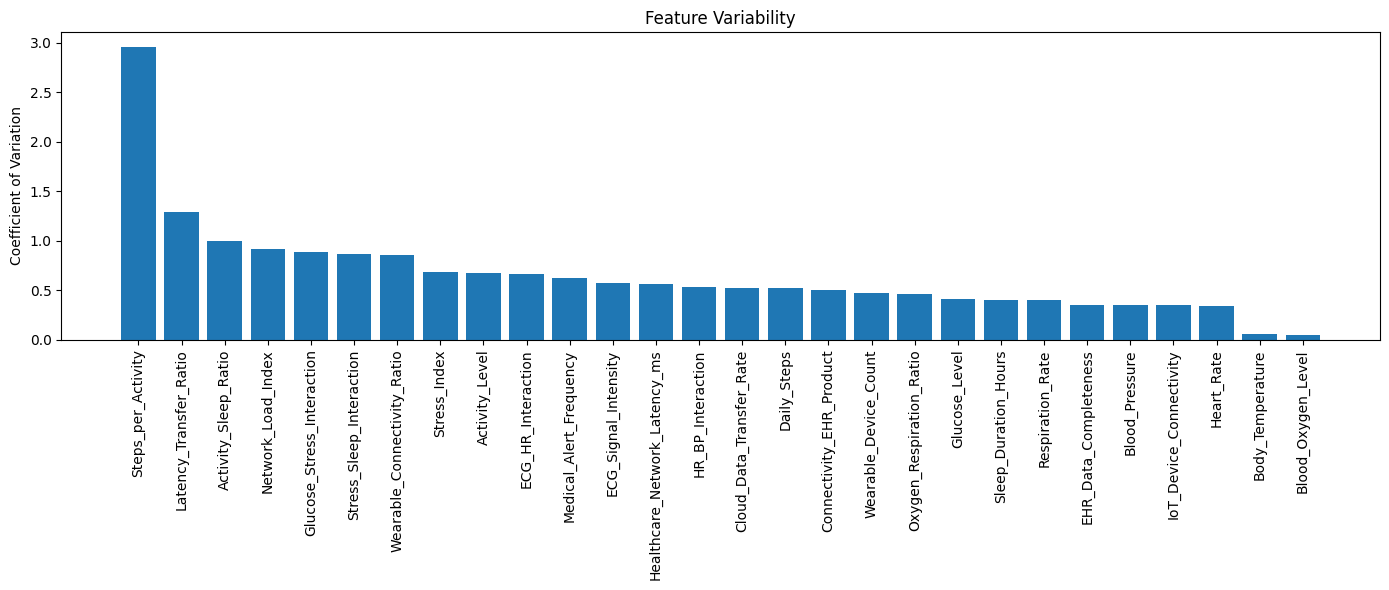

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.bar(
    analysis_df["Feature"],
    analysis_df["Coefficient_of_Variation"]
)

plt.xticks(rotation=90)

plt.ylabel("Coefficient of Variation")

plt.title("Feature Variability")

plt.tight_layout()

plt.show()

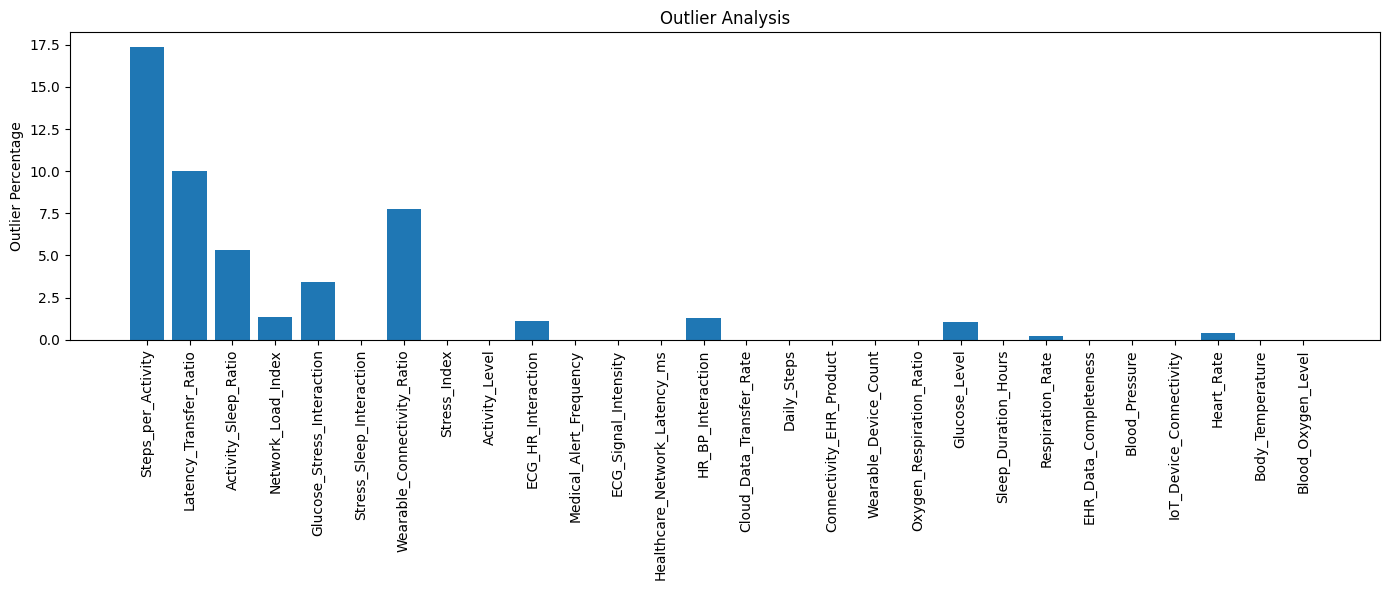

In [ ]:
plt.figure(figsize=(14,6))

plt.bar(
    analysis_df["Feature"],
    analysis_df["Outlier_Percentage"]
)

plt.xticks(rotation=90)

plt.ylabel("Outlier Percentage")

plt.title("Outlier Analysis")

plt.tight_layout()

plt.show()

In [ ]:
#@title step-6 (activity-aware analysis)
import seaborn as sns

plt.style.use("default")

In [ ]:
activity_features = [
    "Activity_Level",
    "Daily_Steps",
    "Sleep_Duration_Hours",
    "Stress_Index"
]

In [ ]:
import seaborn as sns

plt.style.use("default")
#@title Create Activity–Health Profile Table
activity_profile = (
    df_fe
    .groupby("Patient_Health_Status_Label")[activity_features]
    .agg(["mean","std","median","min","max"])
)

display(activity_profile)

Activity_Level                             \
                                      mean        std median min  max   
Patient_Health_Status_Label                                             
Critical                         52.765703  33.937831   54.0   0  100   
High_Risk                        54.373119  33.959331   58.0   0  100   
Moderate_Risk                    53.430569  32.793344   56.0   0  100   
Stable                           36.885886  29.971680   33.0   0  100   

                             Daily_Steps                                     \
                                    mean          std   median   min    max   
Patient_Health_Status_Label                                                   
Critical                     9401.960120  4953.522565   9488.0  1001  17999   
High_Risk                    9459.398195  5013.877407   9501.0  1018  17999   
Moderate_Risk                9214.855145  4917.474694   8966.0  1028  17980   
Stable                       9935.816817  4839.375256  10088.0  1053  17999   

                            Sleep_Duration_Hours                              \
                                            mean       std median  min   max   
Patient_Health_Status_Label                                                    
Critical                                5.689442  2.595615   5.57  2.0  12.0   
High_Risk                               6.871294  2.681235   6.77  2.0  12.0   
Moderate_Risk                           6.998092  2.866011   7.12  2.0  12.0   
Stable                                  8.341572  2.504935   8.48  2.0  12.0   

                            Stress_Index                             
                                    mean        std median min  max  
Patient_Health_Status_Label                                          
Critical                       38.897308  31.321914   35.0   0  100  
High_Risk                      60.202608  33.492268   65.0   0  100  
Moderate_Risk                  43.475524  33.347438   41.0   0  100  
Stable                         58.188188  33.774251   60.0   0  100

In [ ]:
activity_profile.to_csv(
    "Activity_Health_Profile.csv"
)

print("Activity profile table saved.")

Activity profile table saved.


In [ ]:
#@title Mean Activity Table
mean_profile = (
    df_fe
    .groupby("Patient_Health_Status_Label")[activity_features]
    .mean()
)

display(mean_profile)

,Activity_Level,Daily_Steps,Sleep_Duration_Hours,Stress_Index
Patient_Health_Status_Label,,,,
Critical,52.765703,9401.960120,5.689442,38.897308
High_Risk,54.373119,9459.398195,6.871294,60.202608
Moderate_Risk,53.430569,9214.855145,6.998092,43.475524
Stable,36.885886,9935.816817,8.341572,58.188188


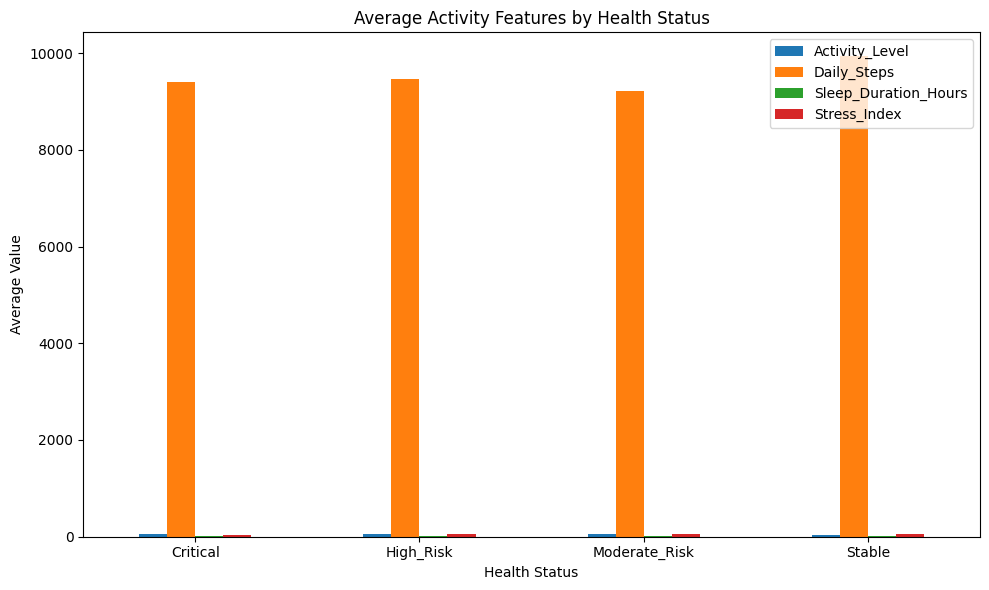

In [ ]:
mean_profile.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Average Activity Features by Health Status")

plt.ylabel("Average Value")

plt.xlabel("Health Status")

plt.xticks(rotation=0)

plt.legend(loc="best")

plt.tight_layout()

plt.show()

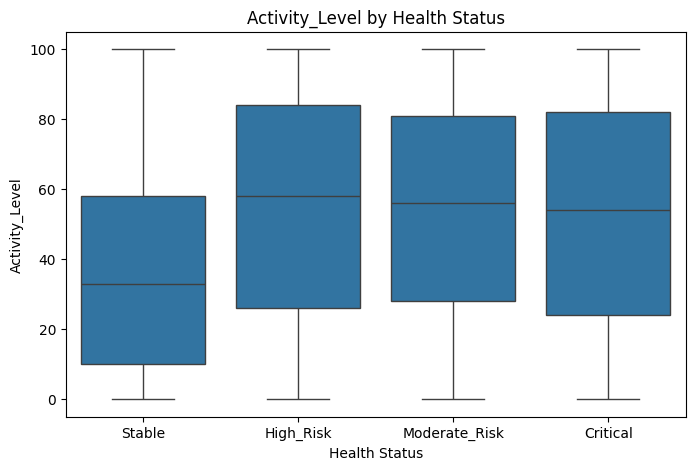

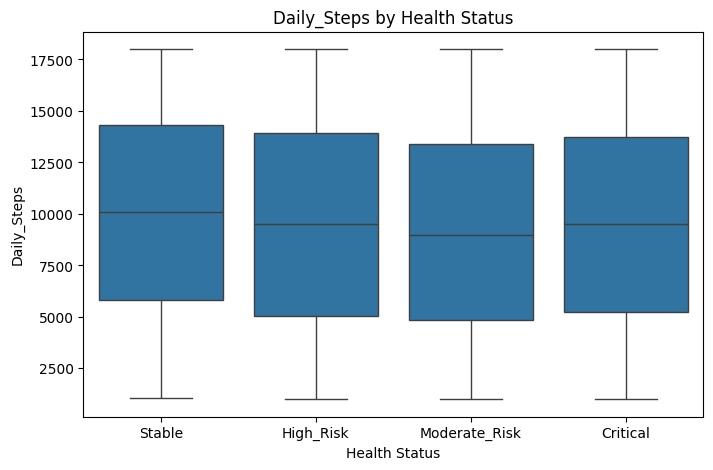

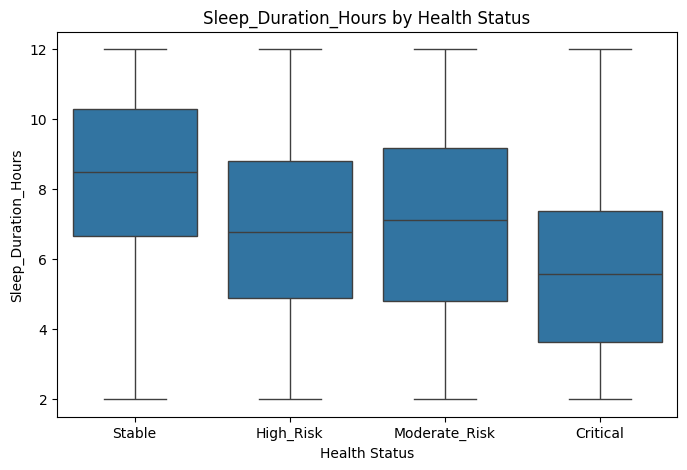

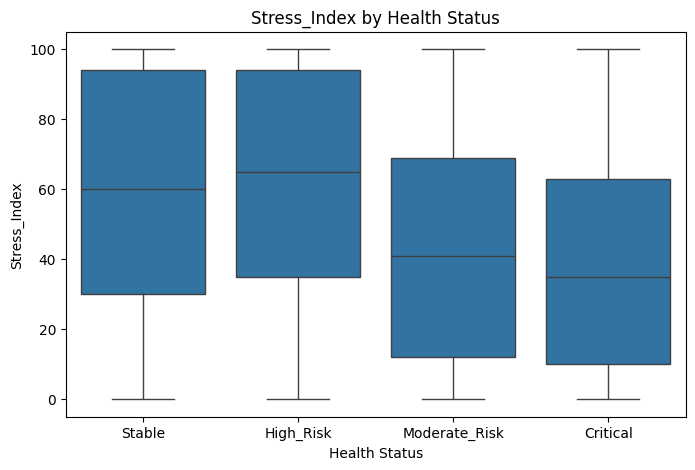

In [ ]:
for feature in activity_features:

    plt.figure(figsize=(8,5))

    sns.boxplot(
        data=df_fe,
        x="Patient_Health_Status_Label",
        y=feature
    )

    plt.title(f"{feature} by Health Status")

    plt.xlabel("Health Status")

    plt.ylabel(feature)

    plt.show()

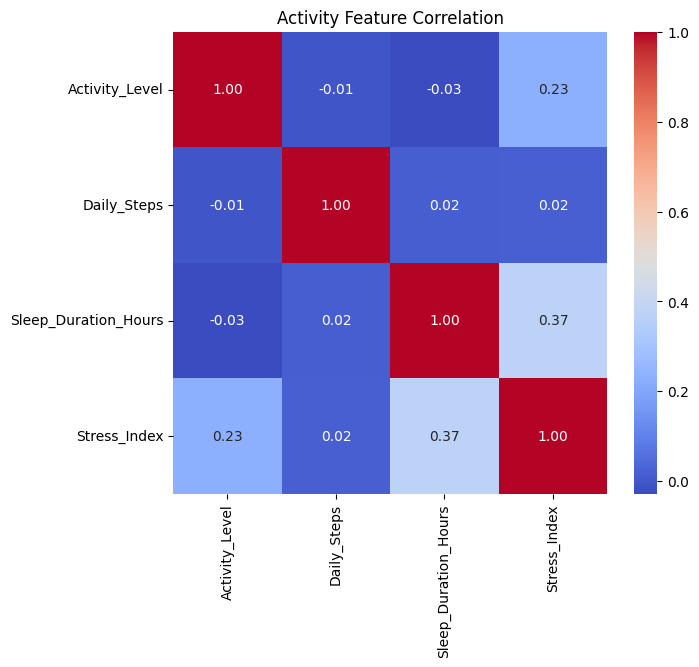

In [ ]:
#@title Correlation Heatmap
plt.figure(figsize=(7,6))

corr = df_fe[activity_features].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Activity Feature Correlation")

plt.show()

In [ ]:
summary = (
    df_fe
    .groupby("Patient_Health_Status_Label")[activity_features]
    .describe()
)

display(summary)

Activity_Level                                   \
                                     count       mean        std  min   25%   
Patient_Health_Status_Label                                                   
Critical                            1003.0  52.765703  33.937831  0.0  24.0   
High_Risk                            997.0  54.373119  33.959331  0.0  26.0   
Moderate_Risk                       1001.0  53.430569  32.793344  0.0  28.0   
Stable                               999.0  36.885886  29.971680  0.0  10.0   

                                               Daily_Steps               ...  \
                              50%   75%    max       count         mean  ...   
Patient_Health_Status_Label                                              ...   
Critical                     54.0  82.0  100.0      1003.0  9401.960120  ...   
High_Risk                    58.0  84.0  100.0       997.0  9459.398195  ...   
Moderate_Risk                56.0  81.0  100.0      1001.0  9214.855145  ...   
Stable                       33.0  58.0  100.0       999.0  9935.816817  ...   

                            Sleep_Duration_Hours       Stress_Index  \
                                             75%   max        count   
Patient_Health_Status_Label                                           
Critical                                    7.37  12.0       1003.0   
High_Risk                                   8.79  12.0        997.0   
Moderate_Risk                               9.18  12.0       1001.0   
Stable                                     10.29  12.0        999.0   

                                                                          \
                                  mean        std  min   25%   50%   75%   
Patient_Health_Status_Label                                                
Critical                     38.897308  31.321914  0.0  10.0  35.0  63.0   
High_Risk                    60.202608  33.492268  0.0  35.0  65.0  94.0   
Moderate_Risk                43.475524  33.347438  0.0  12.0  41.0  69.0   
Stable                       58.188188  33.774251  0.0  30.0  60.0  94.0   

                                    
                               max  
Patient_Health_Status_Label         
Critical                     100.0  
High_Risk                    100.0  
Moderate_Risk                100.0  
Stable                       100.0  

[4 rows x 32 columns]

In [ ]:
#@title Interpret High-Risk Trends
print("="*60)
print("Activity-Aware Analysis Summary")
print("="*60)

for feature in activity_features:

    print(f"\nFeature: {feature}")

    means = (
        df_fe
        .groupby("Patient_Health_Status_Label")[feature]
        .mean()
    )

    print(means)

Activity-Aware Analysis Summary

Feature: Activity_Level
Patient_Health_Status_Label
Critical         52.765703
High_Risk        54.373119
Moderate_Risk    53.430569
Stable           36.885886
Name: Activity_Level, dtype: float64

Feature: Daily_Steps
Patient_Health_Status_Label
Critical         9401.960120
High_Risk        9459.398195
Moderate_Risk    9214.855145
Stable           9935.816817
Name: Daily_Steps, dtype: float64

Feature: Sleep_Duration_Hours
Patient_Health_Status_Label
Critical         5.689442
High_Risk        6.871294
Moderate_Risk    6.998092
Stable           8.341572
Name: Sleep_Duration_Hours, dtype: float64

Feature: Stress_Index
Patient_Health_Status_Label
Critical         38.897308
High_Risk        60.202608
Moderate_Risk    43.475524
Stable           58.188188
Name: Stress_Index, dtype: float64


In [ ]:
summary.to_csv(
    "Step6_ActivityAware_Analysis.csv"
)

print("Step 6 completed successfully.")

Step 6 completed successfully.


In [ ]:
#@title step 7 (restore original health label)
plt.style.use("default")
label_map = {
    0: "Stable",
    1: "Moderate_Risk",
    2: "High_Risk",
    3: "Critical"
}

if df_fe["Patient_Health_Status"].dtype != "object":
    df_fe["Health_Status"] = df_fe["Patient_Health_Status"].map(label_map)
else:
    df_fe["Health_Status"] = df_fe["Patient_Health_Status"]

In [ ]:
#@title IoT and Network Features
iot_features = [

    "IoT_Device_Connectivity",

    "Wearable_Device_Count",

    "EHR_Data_Completeness",

    "Healthcare_Network_Latency_ms",

    "Cloud_Data_Transfer_Rate",

    "Medical_Alert_Frequency"

]

In [ ]:
#@title IoT-System & Network Profile Table
iot_profile = (

    df_fe

    .groupby("Health_Status")[iot_features]

    .agg(["mean","std","median","min","max"])

)

display(iot_profile)

IoT_Device_Connectivity                             \
                                 mean        std median min  max   
Health_Status                                                      
Critical                    82.654038  23.336618   96.0  20  100   
High_Risk                   81.462387  23.834853   94.0  20  100   
Moderate_Risk               68.747253  27.292912   71.0  20  100   
Stable                      69.614615  26.619538   72.0  20  100   

              Wearable_Device_Count                           ...  \
                               mean       std median min max  ...   
Health_Status                                                 ...   
Critical                   3.023928  1.412599    3.0   1   5  ...   
High_Risk                  2.949850  1.426053    3.0   1   5  ...   
Moderate_Risk              2.993007  1.418785    3.0   1   5  ...   
Stable                     3.042042  1.448596    3.0   1   5  ...   

              Cloud_Data_Transfer_Rate                                 \
                                  mean        std median   min    max   
Health_Status                                                           
Critical                     52.882213  27.538030  51.79  5.02  99.83   
High_Risk                    52.875807  27.688980  53.59  5.09  99.97   
Moderate_Risk                51.870310  27.460451  51.72  5.01  99.88   
Stable                       52.946727  26.811060  52.14  5.01  99.95   

              Medical_Alert_Frequency                           
                                 mean       std median min max  
Health_Status                                                   
Critical                     7.162512  4.305049    7.0   0  14  
High_Risk                    6.853561  4.425943    7.0   0  14  
Moderate_Risk                6.988012  4.318548    7.0   0  14  
Stable                       6.933934  4.378811    7.0   0  14  

[4 rows x 30 columns]

In [ ]:
iot_profile.to_csv(
    "Step7_IoT_System_Profile.csv"
)

print("IoT-System profile saved.")

IoT-System profile saved.


In [ ]:
#@title Mean Comparison Table
mean_iot = (

    df_fe

    .groupby("Health_Status")[iot_features]

    .mean()

)

display(mean_iot)

,IoT_Device_Connectivity,Wearable_Device_Count,EHR_Data_Completeness,Healthcare_Network_Latency_ms,Cloud_Data_Transfer_Rate,Medical_Alert_Frequency
Health_Status,,,,,,
Critical,82.654038,3.023928,62.868395,125.768694,52.882213,7.162512
High_Risk,81.462387,2.949850,62.807422,124.401204,52.875807,6.853561
Moderate_Risk,68.747253,2.993007,85.110889,126.339660,51.870310,6.988012
Stable,69.614615,3.042042,61.695696,126.199199,52.946727,6.933934


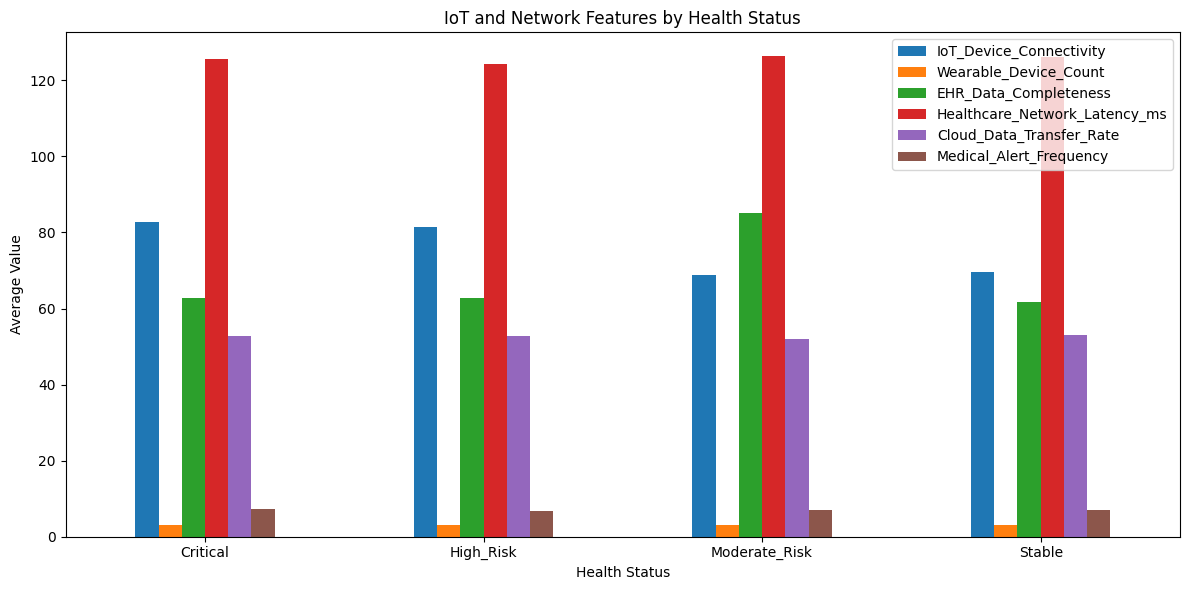

In [ ]:
mean_iot.plot(

    kind="bar",

    figsize=(12,6)

)

plt.title("IoT and Network Features by Health Status")

plt.xlabel("Health Status")

plt.ylabel("Average Value")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

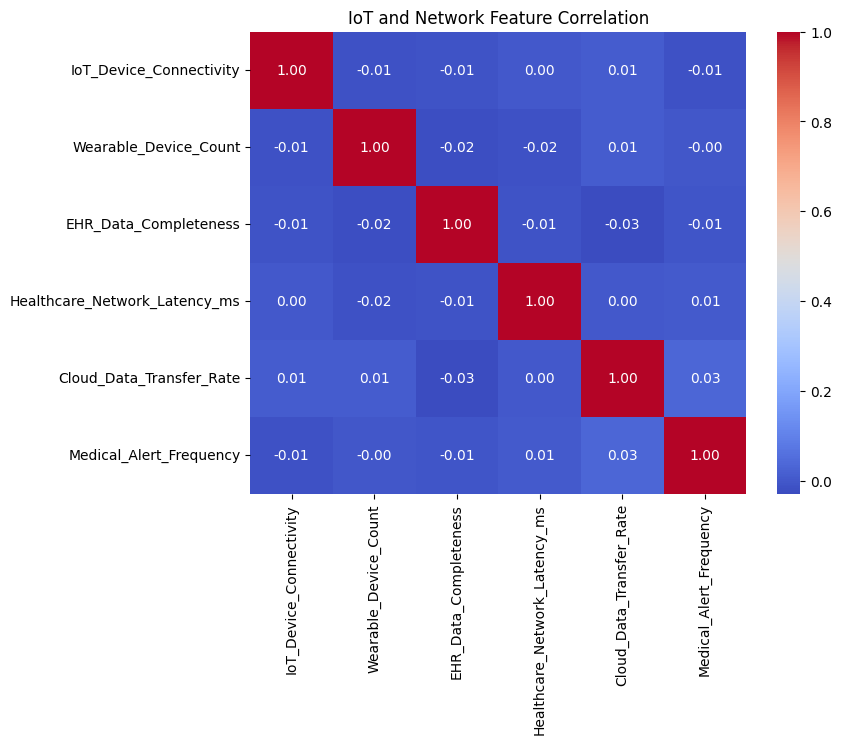

In [ ]:
#@title Correlation Heatmap
plt.figure(figsize=(8,6))

corr = df_fe[iot_features].corr()

sns.heatmap(

    corr,

    annot=True,

    cmap="coolwarm",

    fmt=".2f"

)

plt.title("IoT and Network Feature Correlation")

plt.show()

In [ ]:
summary = (

    df_fe

    .groupby("Health_Status")[iot_features]

    .describe()

)

display(summary)

IoT_Device_Connectivity                                          \
                                count       mean        std   min   25%   50%   
Health_Status                                                                   
Critical                       1003.0  82.654038  23.336618  20.0  69.0  96.0   
High_Risk                       997.0  81.462387  23.834853  20.0  68.0  94.0   
Moderate_Risk                  1001.0  68.747253  27.292912  20.0  47.0  71.0   
Stable                          999.0  69.614615  26.619538  20.0  50.0  72.0   

                            Wearable_Device_Count            ...  \
                 75%    max                 count      mean  ...   
Health_Status                                                ...   
Critical       100.0  100.0                1003.0  3.023928  ...   
High_Risk      100.0  100.0                 997.0  2.949850  ...   
Moderate_Risk  100.0  100.0                1001.0  2.993007  ...   
Stable          99.0  100.0                 999.0  3.042042  ...   

              Cloud_Data_Transfer_Rate        Medical_Alert_Frequency  \
                                   75%    max                   count   
Health_Status                                                           
Critical                        77.405  99.83                  1003.0   
High_Risk                       76.960  99.97                   997.0   
Moderate_Risk                   76.250  99.88                  1001.0   
Stable                          76.215  99.95                   999.0   

                                                              
                   mean       std  min  25%  50%   75%   max  
Health_Status                                                 
Critical       7.162512  4.305049  0.0  4.0  7.0  11.0  14.0  
High_Risk      6.853561  4.425943  0.0  3.0  7.0  11.0  14.0  
Moderate_Risk  6.988012  4.318548  0.0  3.0  7.0  11.0  14.0  
Stable         6.933934  4.378811  0.0  3.0  7.0  11.0  14.0  

[4 rows x 48 columns]

In [ ]:
#@title Monitoring Responsiveness Analysis
print("="*70)
print("Monitoring Responsiveness Analysis")
print("="*70)

latency = (

    df_fe

    .groupby("Health_Status")["Healthcare_Network_Latency_ms"]

    .mean()

)

transfer = (

    df_fe

    .groupby("Health_Status")["Cloud_Data_Transfer_Rate"]

    .mean()

)

print("\nAverage Network Latency (ms)")
print(latency)

print("\nAverage Cloud Data Transfer Rate")
print(transfer)

print("""
NOTE:

Healthcare_Network_Latency_ms and Cloud_Data_Transfer_Rate
are interpreted as proxy indicators of monitoring
responsiveness only.

They DO NOT represent actual collection-to-transmission
delay because the dataset has no timestamp information.
""")

Monitoring Responsiveness Analysis

Average Network Latency (ms)
Health_Status
Critical         125.768694
High_Risk        124.401204
Moderate_Risk    126.339660
Stable           126.199199
Name: Healthcare_Network_Latency_ms, dtype: float64

Average Cloud Data Transfer Rate
Health_Status
Critical         52.882213
High_Risk        52.875807
Moderate_Risk    51.870310
Stable           52.946727
Name: Cloud_Data_Transfer_Rate, dtype: float64

NOTE:

Healthcare_Network_Latency_ms and Cloud_Data_Transfer_Rate
are interpreted as proxy indicators of monitoring
responsiveness only.

They DO NOT represent actual collection-to-transmission
delay because the dataset has no timestamp information.



In [ ]:
#@title Medical Alert Analysis
alerts = (

    df_fe

    .groupby("Health_Status")["Medical_Alert_Frequency"]

    .agg(["mean","std","min","max"])

)

display(alerts)

,mean,std,min,max
Health_Status,,,,
Critical,7.162512,4.305049,0,14
High_Risk,6.853561,4.425943,0,14
Moderate_Risk,6.988012,4.318548,0,14
Stable,6.933934,4.378811,0,14


In [ ]:
#@title Connectivity Analysis
connectivity = (

    df_fe

    .groupby("Health_Status")[

        [

        "IoT_Device_Connectivity",

        "Wearable_Device_Count",

        "EHR_Data_Completeness"

        ]

    ]

    .mean()

)

display(connectivity)

,IoT_Device_Connectivity,Wearable_Device_Count,EHR_Data_Completeness
Health_Status,,,
Critical,82.654038,3.023928,62.868395
High_Risk,81.462387,2.949850,62.807422
Moderate_Risk,68.747253,2.993007,85.110889
Stable,69.614615,3.042042,61.695696


In [ ]:
#@title Radar-Style Comparison Table
comparison = mean_iot.round(2)

display(comparison)

,IoT_Device_Connectivity,Wearable_Device_Count,EHR_Data_Completeness,Healthcare_Network_Latency_ms,Cloud_Data_Transfer_Rate,Medical_Alert_Frequency
Health_Status,,,,,,
Critical,82.65,3.02,62.87,125.77,52.88,7.16
High_Risk,81.46,2.95,62.81,124.40,52.88,6.85
Moderate_Risk,68.75,2.99,85.11,126.34,51.87,6.99
Stable,69.61,3.04,61.70,126.20,52.95,6.93


In [ ]:
comparison.to_csv(
    "Step7_IoT_Network_Analysis.csv"
)

print("Step 7 completed successfully.")

Step 7 completed successfully.


In [ ]:
#@title step-8 (preprocessing)
from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import StandardScaler


In [ ]:
#@title Feature matrix
X = df_fe.drop(columns=[
    "Patient_Health_Status",
    "Patient_Health_Status_Label",
    "Health_Status"          # remove if this column exists
], errors="ignore")

# Target
y = df_fe["Patient_Health_Status"]

print("Feature Matrix:", X.shape)
print("Target:", y.shape)

Feature Matrix: (4000, 28)
Target: (4000,)


In [ ]:
#@title Split before preprocessing

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    stratify=y,

    random_state=42

)

print("Training Samples :", X_train.shape)
print("Testing Samples  :", X_test.shape)

Training Samples : (3200, 28)
Testing Samples  : (800, 28)


In [ ]:
print("Missing Values in Training Data")

display(X_train.isnull().sum())

print()

print("Total Missing Values:",
      X_train.isnull().sum().sum())

Missing Values in Training Data


,0
Heart_Rate,0
Blood_Pressure,0
Blood_Oxygen_Level,0
Body_Temperature,0
Respiration_Rate,0
Glucose_Level,0
ECG_Signal_Intensity,0
Activity_Level,0
Sleep_Duration_Hours,0
Stress_Index,0



Total Missing Values: 0


In [ ]:
#@title Median Imputation

imputer = SimpleImputer(
    strategy="median"
)

# Fit ONLY on training data

X_train_imputed = pd.DataFrame(

    imputer.fit_transform(X_train),

    columns=X_train.columns

)

# Transform test data

X_test_imputed = pd.DataFrame(

    imputer.transform(X_test),

    columns=X_test.columns

)

print("Median Imputation Completed.")

Median Imputation Completed.


In [ ]:
print("Missing Values After Imputation")

print(X_train_imputed.isnull().sum().sum())

print(X_test_imputed.isnull().sum().sum())

Missing Values After Imputation
0
0


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [ ]:
#@title Fit Only on Training Data
X_train_scaled = pd.DataFrame(

    scaler.fit_transform(X_train_imputed),

    columns=X_train.columns

)

X_test_scaled = pd.DataFrame(

    scaler.transform(X_test_imputed),

    columns=X_test.columns

)

print("Scaling Completed.")

Scaling Completed.


In [ ]:
print("Training Mean")

print(round(X_train_scaled.mean(),2))

print()

print("Training Standard Deviation")

print(round(X_train_scaled.std(),2))

Training Mean
Heart_Rate                      -0.0
Blood_Pressure                  -0.0
Blood_Oxygen_Level               0.0
Body_Temperature                 0.0
Respiration_Rate                -0.0
Glucose_Level                   -0.0
ECG_Signal_Intensity            -0.0
Activity_Level                  -0.0
Sleep_Duration_Hours            -0.0
Stress_Index                     0.0
IoT_Device_Connectivity         -0.0
EHR_Data_Completeness            0.0
Wearable_Device_Count           -0.0
Daily_Steps                     -0.0
Healthcare_Network_Latency_ms   -0.0
Cloud_Data_Transfer_Rate         0.0
Medical_Alert_Frequency          0.0
HR_BP_Interaction               -0.0
Oxygen_Respiration_Ratio        -0.0
Glucose_Stress_Interaction       0.0
ECG_HR_Interaction              -0.0
Activity_Sleep_Ratio            -0.0
Steps_per_Activity               0.0
Stress_Sleep_Interaction         0.0
Connectivity_EHR_Product        -0.0
Wearable_Connectivity_Ratio      0.0
Latency_Transfer_Ratio  

In [ ]:
#@title Compare Before and After Scaling
comparison = pd.DataFrame({

    "Original Mean":

        X_train_imputed.mean(),

    "Scaled Mean":

        X_train_scaled.mean(),

    "Original Std":

        X_train_imputed.std(),

    "Scaled Std":

        X_train_scaled.std()

})

display(comparison)

,Original Mean,Scaled Mean,Original Std,Scaled Std
Heart_Rate,8.064344e+01,-1.543210e-16,2.720463e+01,1.000156
Blood_Pressure,1.345666e+02,-1.110223e-16,4.750711e+01,1.000156
Blood_Oxygen_Level,9.551417e+01,1.196820e-15,4.602810e+00,1.000156
Body_Temperature,3.653216e+01,4.307665e-16,2.041899e+00,1.000156
Respiration_Rate,1.814438e+01,-6.272760e-17,7.228709e+00,1.000156
Glucose_Level,1.030756e+02,-3.774758e-17,4.211033e+01,1.000156
ECG_Signal_Intensity,2.518667e+00,-3.663736e-17,1.448847e+00,1.000156
Activity_Level,4.927813e+01,-7.438494e-17,3.347025e+01,1.000156
Sleep_Duration_Hours,6.948991e+00,-4.607426e-16,2.828359e+00,1.000156
Stress_Index,5.020406e+01,4.274359e-17,3.454773e+01,1.000156


In [ ]:
X_train_scaled.to_csv(
    "X_train_preprocessed.csv",
    index=False
)

X_test_scaled.to_csv(
    "X_test_preprocessed.csv",
    index=False
)

print("Preprocessed datasets saved.")

Preprocessed datasets saved.


In [ ]:
print("="*70)
print("STEP 8 COMPLETED")
print("="*70)

print("""

✓ Dataset split into training and testing sets

✓ Median imputation applied

✓ Missing values removed

✓ StandardScaler fitted ONLY on training data

✓ Test data transformed using the fitted scaler

✓ Dataset ready for Step 9

""")

STEP 8 COMPLETED


✓ Dataset split into training and testing sets

✓ Median imputation applied

✓ Missing values removed

✓ StandardScaler fitted ONLY on training data

✓ Test data transformed using the fitted scaler

✓ Dataset ready for Step 9




In [ ]:
#@title step 9 (spliting)
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold
)

In [ ]:
#@title Prepare Features and Target
# Feature matrix
X = df_fe.drop(columns=[
    "Patient_Health_Status",
    "Patient_Health_Status_Label",
    "Health_Status"
], errors="ignore")

# Target
y = df_fe["Patient_Health_Status"]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (4000, 28)
Target Shape: (4000,)


In [ ]:
#@title train-test stratified
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    stratify=y,

    random_state=42

)

print("="*60)
print("Train-Test Split")
print("="*60)

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

print()

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Train-Test Split
Training Samples : 3200
Testing Samples  : 800

Training Shape : (3200, 28)
Testing Shape  : (800, 28)


In [ ]:
print("="*60)
print("Training Class Distribution")
print("="*60)

print(y_train.value_counts())

print()

print("="*60)
print("Testing Class Distribution")
print("="*60)

print(y_test.value_counts())

Training Class Distribution
Patient_Health_Status
3    802
1    801
0    799
2    798
Name: count, dtype: int64

Testing Class Distribution
Patient_Health_Status
3    201
0    200
1    200
2    199
Name: count, dtype: int64


In [ ]:
print("Training Percentage")

display(
    round(
        y_train.value_counts(normalize=True)*100,
        2
    )
)

print("Testing Percentage")

display(
    round(
        y_test.value_counts(normalize=True)*100,
        2
    )
)

Training Percentage


,proportion
Patient_Health_Status,
3,25.06
1,25.03
0,24.97
2,24.94


Testing Percentage


,proportion
Patient_Health_Status,
3,25.12
0,25.00
1,25.00
2,24.88


In [ ]:
#@title Stratified 5-Fold Cross Validation
cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42

)

print(cv)

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


In [ ]:
#@title Display Fold Information
fold = 1

for train_index, valid_index in cv.split(X_train, y_train):

    print("="*60)

    print(f"Fold {fold}")

    print("="*60)

    print("Training Samples :", len(train_index))

    print("Validation Samples :", len(valid_index))

    fold += 1

Fold 1
Training Samples : 2560
Validation Samples : 640
Fold 2
Training Samples : 2560
Validation Samples : 640
Fold 3
Training Samples : 2560
Validation Samples : 640
Fold 4
Training Samples : 2560
Validation Samples : 640
Fold 5
Training Samples : 2560
Validation Samples : 640


In [ ]:
fold = 1

for train_idx, valid_idx in cv.split(X_train, y_train):

    print(f"\nFold {fold}")

    print("Train")

    print(
        y_train.iloc[train_idx].value_counts(normalize=True)
    )

    print()

    print("Validation")

    print(
        y_train.iloc[valid_idx].value_counts(normalize=True)
    )

    fold += 1


Fold 1
Train
Patient_Health_Status
3    0.250781
1    0.250000
0    0.250000
2    0.249219
Name: proportion, dtype: float64

Validation
Patient_Health_Status
1    0.251563
3    0.250000
2    0.250000
0    0.248438
Name: proportion, dtype: float64

Fold 2
Train
Patient_Health_Status
3    0.250781
1    0.250391
0    0.249609
2    0.249219
Name: proportion, dtype: float64

Validation
Patient_Health_Status
3    0.25
0    0.25
2    0.25
1    0.25
Name: proportion, dtype: float64

Fold 3
Train
Patient_Health_Status
3    0.250781
1    0.250391
0    0.249609
2    0.249219
Name: proportion, dtype: float64

Validation
Patient_Health_Status
2    0.25
0    0.25
1    0.25
3    0.25
Name: proportion, dtype: float64

Fold 4
Train
Patient_Health_Status
1    0.250391
3    0.250391
0    0.249609
2    0.249609
Name: proportion, dtype: float64

Validation
Patient_Health_Status
3    0.251563
1    0.250000
0    0.250000
2    0.248438
Name: proportion, dtype: float64

Fold 5
Train
Patient_Health_Status
1   

In [ ]:
#@title experiment
random_seeds = [

    42,

    123,

    2024,

    777,

    999

]

print("Random Seeds")

print(random_seeds)

Random Seeds
[42, 123, 2024, 777, 999]


In [ ]:
#@title Generate Splits for Each Seed
splits = {}

for seed in random_seeds:

    X_train_seed, X_test_seed, y_train_seed, y_test_seed = train_test_split(

        X,

        y,

        test_size=0.20,

        stratify=y,

        random_state=seed

    )

    splits[seed] = {

        "X_train": X_train_seed,

        "X_test": X_test_seed,

        "y_train": y_train_seed,

        "y_test": y_test_seed

    }

print("Repeated splits created successfully.")

Repeated splits created successfully.


In [ ]:
#@title step 10 (training base models)
import numpy as np
import pandas as pd

from sklearn.model_selection import cross_val_score

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Baseline Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [ ]:
models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=1000,
            random_state=42
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ),

    "Support Vector Machine":
        SVC(
            kernel="rbf",
            random_state=42
        ),

    "K-Nearest Neighbor":
        KNeighborsClassifier(
            n_neighbors=5
        ),

    "Naive Bayes":
        GaussianNB()
}

In [ ]:
#@title train and evaluate models
results = []

for name, model in models.items():

    print("="*70)
    print(name)
    print("="*70)

    # -------------------------
    # Cross Validation
    # -------------------------

    cv_scores = cross_val_score(

        model,

        X_train_scaled,

        y_train,

        cv=cv,

        scoring="accuracy"

    )

    print("Cross Validation Accuracy")

    print(cv_scores)

    print("Mean Accuracy:",
          round(cv_scores.mean(),4))

    # -------------------------
    # Train Model
    # -------------------------

    model.fit(

        X_train_scaled,

        y_train

    )

    # -------------------------
    # Predict
    # -------------------------

    y_pred = model.predict(
        X_test_scaled
    )

    # -------------------------
    # Metrics
    # -------------------------

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        average="macro"
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="macro"
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="macro"
    )

    print()

    print("Accuracy :", accuracy)

    print("Precision:", precision)

    print("Recall   :", recall)

    print("F1 Score :", f1)

    results.append([

        name,

        cv_scores.mean(),

        accuracy,

        precision,

        recall,

        f1

    ])

Logistic Regression
Cross Validation Accuracy
[0.7       0.6859375 0.7       0.69375   0.7171875]
Mean Accuracy: 0.6994

Accuracy : 0.6725
Precision: 0.6712361712361712
Recall   : 0.6726078776969424
F1 Score : 0.6716834164510359
Decision Tree
Cross Validation Accuracy
[0.6265625 0.634375  0.671875  0.66875   0.640625 ]
Mean Accuracy: 0.6484

Accuracy : 0.645
Precision: 0.6454859606356085
Recall   : 0.6450201880047002
F1 Score : 0.6450118082921538
Random Forest
Cross Validation Accuracy
[0.8140625 0.7953125 0.7859375 0.8078125 0.8171875]
Mean Accuracy: 0.8041

Accuracy : 0.79125
Precision: 0.7912718645215963
Recall   : 0.7913409710242756
F1 Score : 0.791142434818977
Support Vector Machine
Cross Validation Accuracy
[0.8015625 0.8171875 0.8046875 0.809375  0.8203125]
Mean Accuracy: 0.8106

Accuracy : 0.8
Precision: 0.801097067459444
Recall   : 0.800134628365709
F1 Score : 0.7994484450331513
K-Nearest Neighbor
Cross Validation Accuracy
[0.75625   0.734375  0.7484375 0.71875   0.740625 ]
Me

In [ ]:
results_df = pd.DataFrame(

    results,

    columns=[

        "Model",

        "CV Accuracy",

        "Test Accuracy",

        "Precision",

        "Recall",

        "F1 Score"

    ]

)

display(results_df)

,Model,CV Accuracy,Test Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.699375,0.67250,0.671236,0.672608,0.671683
1,Decision Tree,0.648438,0.64500,0.645486,0.645020,0.645012
2,Random Forest,0.804063,0.79125,0.791272,0.791341,0.791142
3,Support Vector Machine,0.810625,0.80000,0.801097,0.800135,0.799448
4,K-Nearest Neighbor,0.739688,0.73375,0.735870,0.733971,0.732338
5,Naive Bayes,0.640625,0.60250,0.603779,0.602582,0.601360


In [ ]:
#@title result sorting
results_df = results_df.sort_values(

    by="F1 Score",

    ascending=False

)

display(results_df)

,Model,CV Accuracy,Test Accuracy,Precision,Recall,F1 Score
3,Support Vector Machine,0.810625,0.80000,0.801097,0.800135,0.799448
2,Random Forest,0.804063,0.79125,0.791272,0.791341,0.791142
4,K-Nearest Neighbor,0.739688,0.73375,0.735870,0.733971,0.732338
0,Logistic Regression,0.699375,0.67250,0.671236,0.672608,0.671683
1,Decision Tree,0.648438,0.64500,0.645486,0.645020,0.645012
5,Naive Bayes,0.640625,0.60250,0.603779,0.602582,0.601360


In [ ]:
#@title classification report
for name, model in models.items():

    print("="*70)

    print(name)

    print("="*70)

    predictions = model.predict(
        X_test_scaled
    )

    print(

        classification_report(

            y_test,

            predictions

        )

    )

Logistic Regression
              precision    recall  f1-score   support

           0       0.73      0.76      0.74       200
           1       0.67      0.67      0.67       200
           2       0.67      0.67      0.67       199
           3       0.62      0.59      0.61       201

    accuracy                           0.67       800
   macro avg       0.67      0.67      0.67       800
weighted avg       0.67      0.67      0.67       800

Decision Tree
              precision    recall  f1-score   support

           0       0.69      0.68      0.68       200
           1       0.63      0.68      0.65       200
           2       0.65      0.62      0.63       199
           3       0.61      0.61      0.61       201

    accuracy                           0.65       800
   macro avg       0.65      0.65      0.65       800
weighted avg       0.65      0.65      0.64       800

Random Forest
              precision    recall  f1-score   support

           0       0.82    

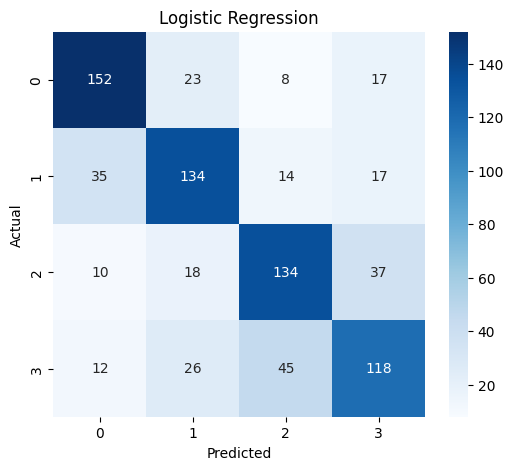

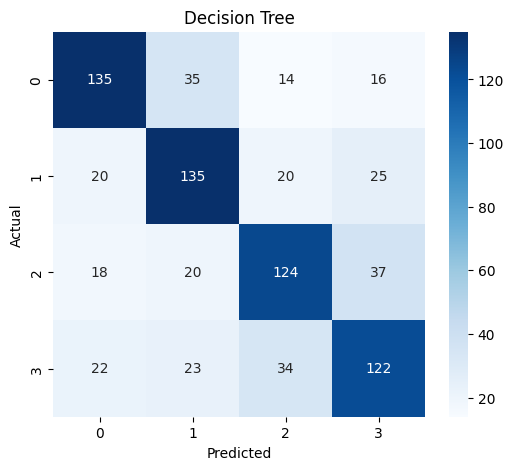

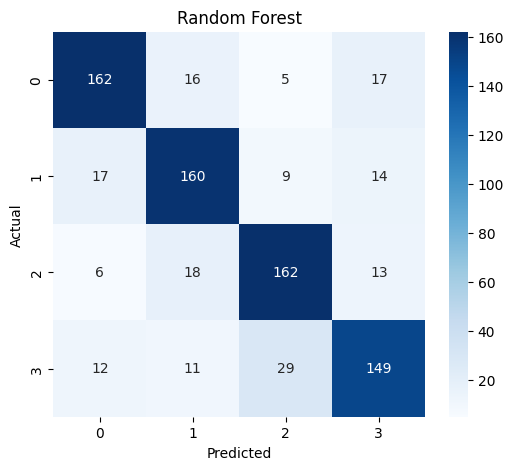

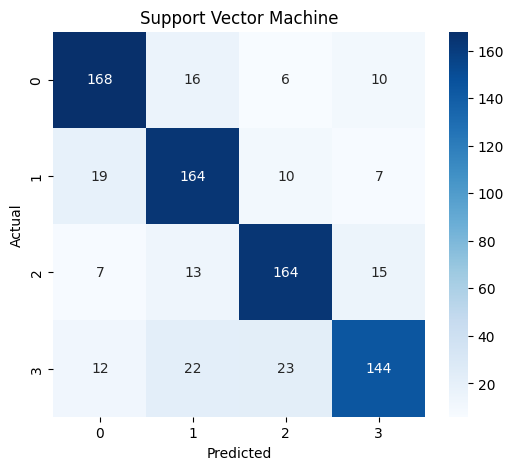

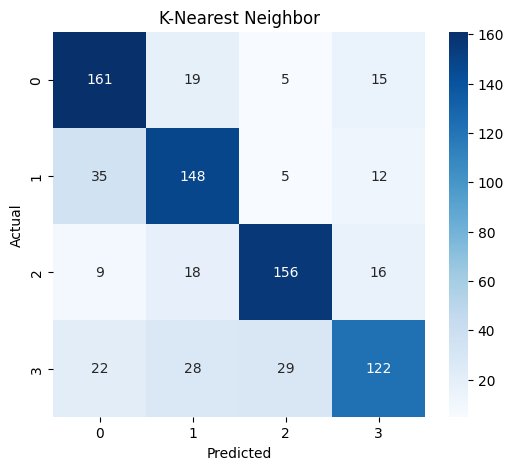

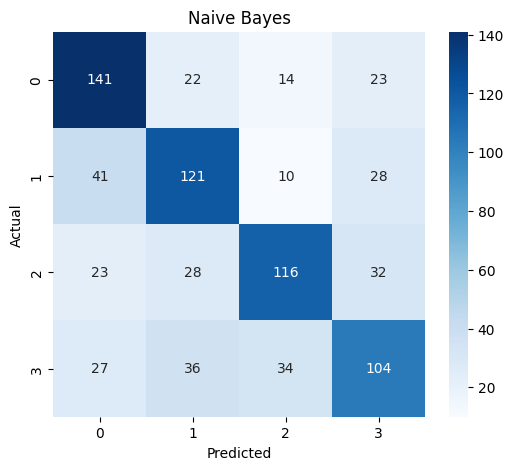

In [ ]:
#@title confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns

for name, model in models.items():

    predictions = model.predict(
        X_test_scaled
    )

    cm = confusion_matrix(

        y_test,

        predictions

    )

    plt.figure(figsize=(6,5))

    sns.heatmap(

        cm,

        annot=True,

        fmt="d",

        cmap="Blues"

    )

    plt.title(name)

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

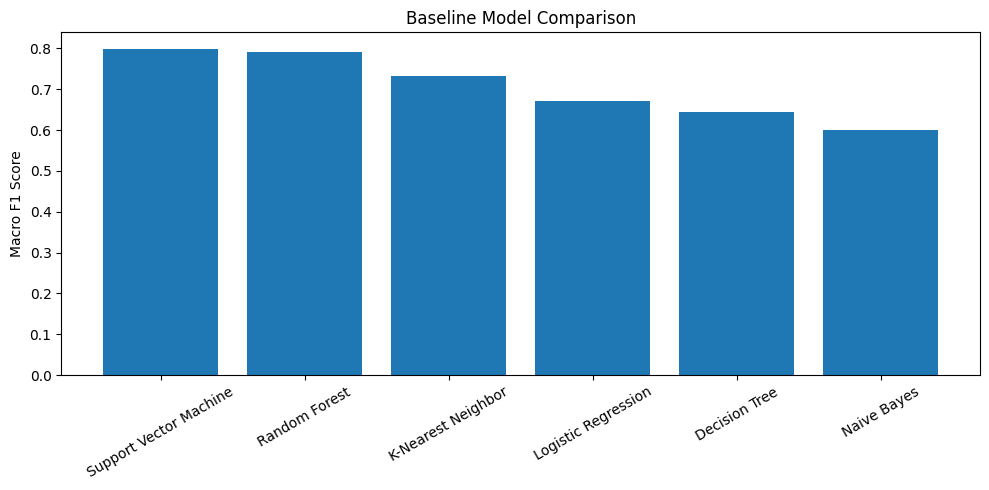

In [ ]:
#@title comparison
plt.figure(figsize=(10,5))

plt.bar(

    results_df["Model"],

    results_df["F1 Score"]

)

plt.xticks(rotation=30)

plt.ylabel("Macro F1 Score")

plt.title("Baseline Model Comparison")

plt.tight_layout()

plt.show()

In [ ]:
results_df.to_csv(

    "Step10_Baseline_Model_Results.csv",

    index=False

)

print("Baseline model results saved.")

Baseline model results saved.


In [ ]:
best_model = results_df.iloc[0]

print("="*70)
print("BEST BASELINE MODEL")
print("="*70)

print(best_model)

BEST BASELINE MODEL
Model            Support Vector Machine
CV Accuracy                    0.810625
Test Accuracy                       0.8
Precision                      0.801097
Recall                         0.800135
F1 Score                       0.799448
Name: 3, dtype: object


In [ ]:
#@title step-11 (Train advanced tabular baselines)
!pip install -q pytorch-tabnet
!pip install -q tab-transformer-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.3 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd

import torch

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from pytorch_tabnet.tab_model import TabNetClassifier

from tab_transformer_pytorch import TabTransformer

In [ ]:
print("X_train shape:", X_train_scaled.shape)
print("X_test shape :", X_test_scaled.shape)

print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (3200, 28)
X_test shape : (800, 28)
y_train shape: (3200,)
y_test shape : (800,)


In [ ]:
#@title Convert Data to NumPy
X_train_np = X_train_scaled.values.astype(np.float32)

X_test_np = X_test_scaled.values.astype(np.float32)

y_train_np = y_train.values.astype(np.int64)

y_test_np = y_test.values.astype(np.int64)

print("Training Features:", X_train_np.shape)
print("Testing Features :", X_test_np.shape)

Training Features: (3200, 28)
Testing Features : (800, 28)


In [ ]:
#@title tabnet model
tabnet_model = TabNetClassifier(

    n_d=16,

    n_a=16,

    n_steps=5,

    gamma=1.5,

    lambda_sparse=1e-4,

    optimizer_fn=torch.optim.Adam,

    optimizer_params=dict(
        lr=2e-2
    ),

    mask_type="entmax",

    seed=42,

    verbose=10
)

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


In [ ]:
#@title train tabnet
tabnet_model.fit(

    X_train_np,

    y_train_np,

    eval_set=[
        (X_train_np, y_train_np),
        (X_test_np, y_test_np)
    ],

    eval_name=[
        "train",
        "test"
    ],

    eval_metric=[
        "accuracy"
    ],

    max_epochs=100,

    patience=20,

    batch_size=256,

    virtual_batch_size=128,

    num_workers=0,

    drop_last=False

)

epoch 0  | loss: 1.70508 | train_accuracy: 0.37844 | test_accuracy: 0.385   |  0:00:02s
epoch 10 | loss: 0.81384 | train_accuracy: 0.68719 | test_accuracy: 0.64875 |  0:00:24s
epoch 20 | loss: 0.59184 | train_accuracy: 0.77969 | test_accuracy: 0.70375 |  0:00:35s
epoch 30 | loss: 0.52394 | train_accuracy: 0.83938 | test_accuracy: 0.76    |  0:00:44s
epoch 40 | loss: 0.42359 | train_accuracy: 0.85844 | test_accuracy: 0.775   |  0:00:53s
epoch 50 | loss: 0.35329 | train_accuracy: 0.91    | test_accuracy: 0.80625 |  0:01:01s
epoch 60 | loss: 0.2965  | train_accuracy: 0.90875 | test_accuracy: 0.785   |  0:01:09s
epoch 70 | loss: 0.31034 | train_accuracy: 0.91656 | test_accuracy: 0.7875  |  0:01:18s

Early stopping occurred at epoch 70 with best_epoch = 50 and best_test_accuracy = 0.80625


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [ ]:
#@title tabnet prediction
tabnet_pred = tabnet_model.predict(
    X_test_np
)

print("TabNet Predictions:")
print(tabnet_pred[:10])

TabNet Predictions:
[2 0 3 3 1 2 1 2 2 1]


In [ ]:
#@title evaluation
tabnet_accuracy = accuracy_score(
    y_test_np,
    tabnet_pred
)

tabnet_precision = precision_score(
    y_test_np,
    tabnet_pred,
    average="macro",
    zero_division=0
)

tabnet_recall = recall_score(
    y_test_np,
    tabnet_pred,
    average="macro",
    zero_division=0
)

tabnet_f1 = f1_score(
    y_test_np,
    tabnet_pred,
    average="macro",
    zero_division=0
)

print("TabNet Results")
print("-" * 40)

print("Accuracy :", round(tabnet_accuracy, 4))
print("Precision:", round(tabnet_precision, 4))
print("Recall   :", round(tabnet_recall, 4))
print("Macro F1 :", round(tabnet_f1, 4))

TabNet Results
----------------------------------------
Accuracy : 0.8063
Precision: 0.8067
Recall   : 0.8063
Macro F1 : 0.8059


In [ ]:
#@title tabnet classification
print(
    classification_report(
        y_test_np,
        tabnet_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.79      0.85      0.82       200
           1       0.80      0.80      0.80       200
           2       0.83      0.82      0.82       199
           3       0.81      0.75      0.78       201

    accuracy                           0.81       800
   macro avg       0.81      0.81      0.81       800
weighted avg       0.81      0.81      0.81       800



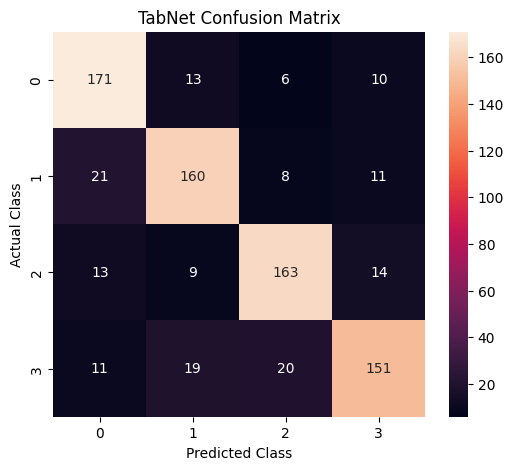

In [ ]:
#@title confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_tabnet = confusion_matrix(
    y_test_np,
    tabnet_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_tabnet,
    annot=True,
    fmt="d"
)

plt.title("TabNet Confusion Matrix")

plt.xlabel("Predicted Class")

plt.ylabel("Actual Class")

plt.show()

In [ ]:
!pip install -q rtdl-revisiting-models

In [ ]:
import torch
import torch.nn as nn

from rtdl_revisiting_models import FTTransformer

In [ ]:
print("Training data shape:", X_train_scaled.shape)
print("Testing data shape :", X_test_scaled.shape)

print("Number of classes:", len(np.unique(y_train)))

Training data shape: (3200, 28)
Testing data shape : (800, 28)
Number of classes: 4


In [ ]:
#@title ft transformer
# Convert scaled numerical features to float32 tensors

X_train_ft = torch.tensor(
    X_train_scaled.values,
    dtype=torch.float32
)

X_test_ft = torch.tensor(
    X_test_scaled.values,
    dtype=torch.float32
)

# Convert target to long tensors

y_train_ft = torch.tensor(
    y_train.values,
    dtype=torch.long
)

y_test_ft = torch.tensor(
    y_test.values,
    dtype=torch.long
)

print("X_train:", X_train_ft.shape)
print("X_test :", X_test_ft.shape)
print("y_train:", y_train_ft.shape)
print("y_test :", y_test_ft.shape)

X_train: torch.Size([3200, 28])
X_test : torch.Size([800, 28])
y_train: torch.Size([3200])
y_test : torch.Size([800])


In [ ]:
#@title Training and Validation Split
from sklearn.model_selection import train_test_split

X_ft_train, X_ft_val, y_ft_train, y_ft_val = train_test_split(

    X_train_ft,

    y_train_ft,

    test_size=0.20,

    stratify=y_train_ft,

    random_state=42

)

print("FT-Transformer Training:", X_ft_train.shape)
print("FT-Transformer Validation:", X_ft_val.shape)
print("Final Test:", X_test_ft.shape)

FT-Transformer Training: torch.Size([2560, 28])
FT-Transformer Validation: torch.Size([640, 28])
Final Test: torch.Size([800, 28])


In [ ]:
#@title Create DataLoaders
from torch.utils.data import TensorDataset, DataLoader

# Training dataset

ft_train_dataset = TensorDataset(
    X_ft_train,
    y_ft_train
)

# Validation dataset

ft_val_dataset = TensorDataset(
    X_ft_val,
    y_ft_val
)

# Test dataset

ft_test_dataset = TensorDataset(
    X_test_ft,
    y_test_ft
)

# DataLoaders

ft_train_loader = DataLoader(
    ft_train_dataset,
    batch_size=64,
    shuffle=True
)

ft_val_loader = DataLoader(
    ft_val_dataset,
    batch_size=128,
    shuffle=False
)

ft_test_loader = DataLoader(
    ft_test_dataset,
    batch_size=128,
    shuffle=False
)

print("DataLoaders created successfully.")

DataLoaders created successfully.


In [ ]:
#@title Define
num_features = X_train_ft.shape[1]

num_classes = len(
    np.unique(
        y_train_ft.numpy()
    )
)

print("Number of Features:", num_features)
print("Number of Classes:", num_classes)

Number of Features: 28
Number of Classes: 4


In [ ]:
ft_model = FTTransformer(

    n_cont_features=num_features,

    cat_cardinalities=None,

    d_out=num_classes,

    d_block=192,

    n_blocks=3,

    attention_n_heads=8,

    attention_dropout=0.2,

    ffn_d_hidden_multiplier=2,

    ffn_dropout=0.1,

    residual_dropout=0.0

)

In [ ]:
device = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else "cpu"

)

print("Using device:", device)

ft_model = ft_model.to(device)

Using device: cpu


In [ ]:
#@title Define Loss and Optimizer
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(

    ft_model.parameters(),

    lr=1e-4,

    weight_decay=1e-5

)

In [ ]:
#@title training
num_epochs = 50

best_val_loss = float("inf")

patience = 10

patience_counter = 0

best_model_state = None


for epoch in range(num_epochs):

    # ==================================================
    # TRAINING
    # ==================================================

    ft_model.train()

    train_loss = 0.0

    for batch_X, batch_y in ft_train_loader:

        batch_X = batch_X.to(device)

        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        # FT-Transformer expects:
        # x_num = numerical features
        # x_cat = categorical features

        output = ft_model(

            batch_X,

            None

        )

        loss = criterion(

            output,

            batch_y

        )

        loss.backward()

        optimizer.step()

        train_loss += loss.item()


    # ==================================================
    # VALIDATION
    # ==================================================

    ft_model.eval()

    val_loss = 0.0

    with torch.no_grad():

        for batch_X, batch_y in ft_val_loader:

            batch_X = batch_X.to(device)

            batch_y = batch_y.to(device)

            output = ft_model(

                batch_X,

                None

            )

            loss = criterion(

                output,

                batch_y

            )

            val_loss += loss.item()


    # Average losses

    train_loss /= len(ft_train_loader)

    val_loss /= len(ft_val_loader)


    # ==================================================
    # PRINT PROGRESS
    # ==================================================

    print(

        f"Epoch {epoch+1}/{num_epochs} | "

        f"Train Loss: {train_loss:.4f} | "

        f"Validation Loss: {val_loss:.4f}"

    )


    # ==================================================
    # EARLY STOPPING
    # ==================================================

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        patience_counter = 0

        best_model_state = (

            ft_model.state_dict()

        )

    else:

        patience_counter += 1

        if patience_counter >= patience:

            print(
                "Early stopping triggered."
            )

            break

Epoch 1/50 | Train Loss: 1.1234 | Validation Loss: 0.8248
Epoch 2/50 | Train Loss: 0.8587 | Validation Loss: 0.7035
Epoch 3/50 | Train Loss: 0.7720 | Validation Loss: 0.6929
Epoch 4/50 | Train Loss: 0.7017 | Validation Loss: 0.6230
Epoch 5/50 | Train Loss: 0.6314 | Validation Loss: 0.6099
Epoch 6/50 | Train Loss: 0.5981 | Validation Loss: 0.5852
Epoch 7/50 | Train Loss: 0.5611 | Validation Loss: 0.5864
Epoch 8/50 | Train Loss: 0.5274 | Validation Loss: 0.5131
Epoch 9/50 | Train Loss: 0.4812 | Validation Loss: 0.5241
Epoch 10/50 | Train Loss: 0.4509 | Validation Loss: 0.4972
Epoch 11/50 | Train Loss: 0.4348 | Validation Loss: 0.4718
Epoch 12/50 | Train Loss: 0.3978 | Validation Loss: 0.5051
Epoch 13/50 | Train Loss: 0.3719 | Validation Loss: 0.4833
Epoch 14/50 | Train Loss: 0.3510 | Validation Loss: 0.4681
Epoch 15/50 | Train Loss: 0.3378 | Validation Loss: 0.4570
Epoch 16/50 | Train Loss: 0.3207 | Validation Loss: 0.4421
Epoch 17/50 | Train Loss: 0.2999 | Validation Loss: 0.4787
Epoch 

In [ ]:
if best_model_state is not None:

    ft_model.load_state_dict(
        best_model_state
    )

print(
    "Best FT-Transformer model restored."
)

Best FT-Transformer model restored.


In [ ]:
import numpy as np
import torch

#@title Predictions
ft_model.eval()

ft_predictions = []

with torch.no_grad():

    for batch_X, batch_y in ft_test_loader:

        batch_X = batch_X.to(device)

        output = ft_model(

            batch_X,

            None

        )

        predictions = torch.argmax(

            output,

            dim=1

        )

        ft_predictions.extend(

            predictions.cpu().numpy()

        )

ft_predictions = np.array(
    ft_predictions
)

print(
    "Predictions generated:",
    len(ft_predictions)
)

Predictions generated: 800


In [ ]:
#@title Evaluate FT-Transformer
ft_accuracy = accuracy_score(

    y_test.values,

    ft_predictions

)

ft_precision = precision_score(

    y_test.values,

    ft_predictions,

    average="macro",

    zero_division=0

)

ft_recall = recall_score(

    y_test.values,

    ft_predictions,

    average="macro",

    zero_division=0

)

ft_f1 = f1_score(

    y_test.values,

    ft_predictions,

    average="macro",

    zero_division=0

)


print("=" * 50)

print("FT-TRANSFORMER RESULTS")

print("=" * 50)

print(
    "Accuracy :",
    round(ft_accuracy, 4)
)

print(
    "Precision:",
    round(ft_precision, 4)
)

print(
    "Recall   :",
    round(ft_recall, 4)
)

print(
    "Macro F1 :",
    round(ft_f1, 4)
)

FT-TRANSFORMER RESULTS
Accuracy : 0.7913
Precision: 0.7912
Recall   : 0.7913
Macro F1 : 0.7913


In [ ]:
#@title Classification Report
print(
    classification_report(

        y_test.values,

        ft_predictions,

        target_names=[

            "Stable",

            "Moderate_Risk",

            "High_Risk",

            "Critical"

        ],

        zero_division=0

    )
)

               precision    recall  f1-score   support

       Stable       0.80      0.81      0.81       200
Moderate_Risk       0.78      0.78      0.78       200
    High_Risk       0.82      0.82      0.82       199
     Critical       0.76      0.76      0.76       201

     accuracy                           0.79       800
    macro avg       0.79      0.79      0.79       800
 weighted avg       0.79      0.79      0.79       800



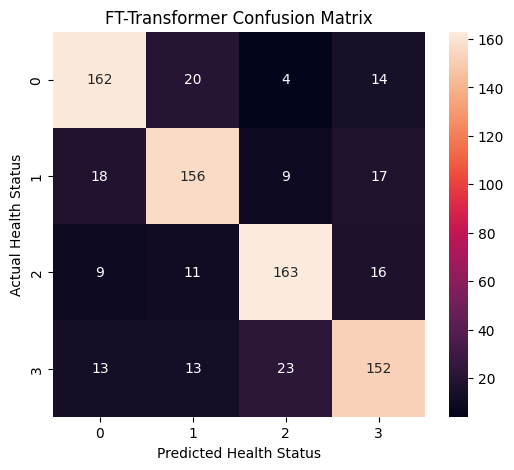

In [ ]:
#@title Confusion Matrix
cm_ft = confusion_matrix(

    y_test.values,

    ft_predictions

)

plt.figure(
    figsize=(6, 5)
)

sns.heatmap(

    cm_ft,

    annot=True,

    fmt="d"

)

plt.title(
    "FT-Transformer Confusion Matrix"
)

plt.xlabel(
    "Predicted Health Status"
)

plt.ylabel(
    "Actual Health Status"
)

plt.show()

In [ ]:
#@title Combine TabNet and FT-Transformer Results
advanced_results = pd.DataFrame({

    "Model": [

        "TabNet",

        "FT-Transformer"

    ],

    "Accuracy": [

        tabnet_accuracy,

        ft_accuracy

    ],

    "Macro Precision": [

        tabnet_precision,

        ft_precision

    ],

    "Macro Recall": [

        tabnet_recall,

        ft_recall

    ],

    "Macro F1": [

        tabnet_f1,

        ft_f1

    ]

})

display(
    advanced_results
)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,TabNet,0.80625,0.806731,0.806335,0.805929
1,FT-Transformer,0.79125,0.791224,0.791329,0.791266


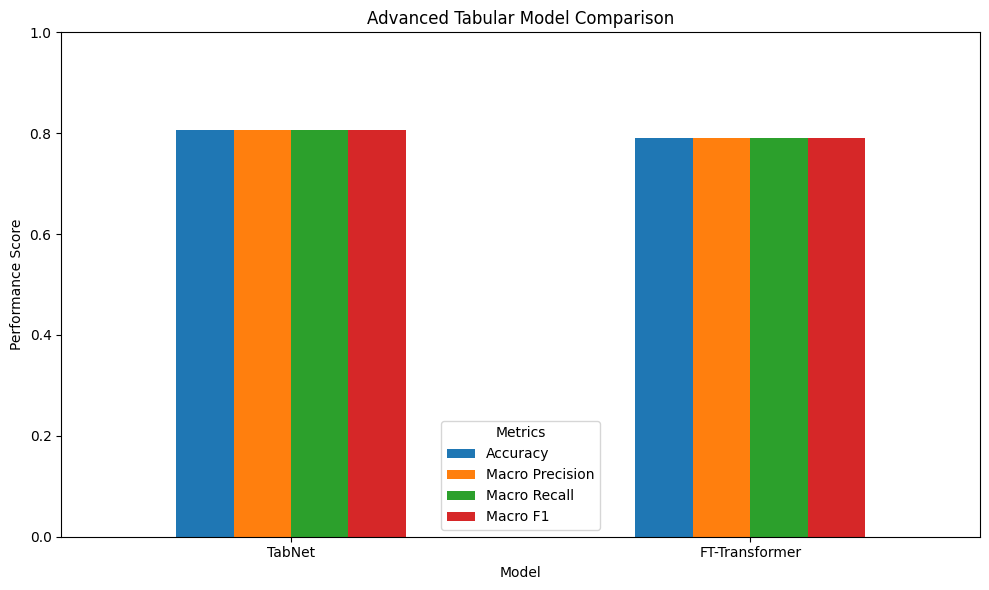

In [ ]:
#@title Compare Advanced Models
advanced_results.plot(

    x="Model",

    y=[

        "Accuracy",

        "Macro Precision",

        "Macro Recall",

        "Macro F1"

    ],

    kind="bar",

    figsize=(10, 6)

)

plt.title(
    "Advanced Tabular Model Comparison"
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "Performance Score"
)

plt.xticks(
    rotation=0
)

plt.ylim(
    0,

    1
)

plt.legend(
    title="Metrics"
)

plt.tight_layout()

plt.show()

In [ ]:
advanced_results.to_csv(

    "Step11_Advanced_Tabular_Baselines.csv",

    index=False

)

print(
    "Step 11 results saved successfully."
)

Step 11 results saved successfully.


In [ ]:
#@title step-12 (OGA-XAI-HIoT)
# STEP 12: OGA-XAI-HIoT
# Ordinal Group-Attention Explainable Healthcare IoT

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    TensorDataset,
    DataLoader
)

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
#@title Set Random Seeds
SEED = 42

np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random seed:", SEED)

Random seed: 42


In [ ]:
print("X_train shape:", X_train_scaled.shape)
print("X_test shape :", X_test_scaled.shape)

print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

print("\nTraining classes:")
print(y_train.value_counts().sort_index())

print("\nTesting classes:")
print(y_test.value_counts().sort_index())

X_train shape: (3200, 28)
X_test shape : (800, 28)
y_train shape: (3200,)
y_test shape : (800,)

Training classes:
Patient_Health_Status
0    799
1    801
2    798
3    802
Name: count, dtype: int64

Testing classes:
Patient_Health_Status
0    200
1    200
2    199
3    201
Name: count, dtype: int64


In [ ]:
#@title Define Health Status Classes
# Target Classes

class_names = [
    "Stable",
    "Moderate_Risk",
    "High_Risk",
    "Critical"
]

NUM_CLASSES = len(class_names)

print("Number of classes:", NUM_CLASSES)
print("Classes:", class_names)

Number of classes: 4
Classes: ['Stable', 'Moderate_Risk', 'High_Risk', 'Critical']


In [ ]:
#@title Define the Feature Groups
print("Available Features:")
print(X_train_scaled.columns.tolist())

Available Features:
['Heart_Rate', 'Blood_Pressure', 'Blood_Oxygen_Level', 'Body_Temperature', 'Respiration_Rate', 'Glucose_Level', 'ECG_Signal_Intensity', 'Activity_Level', 'Sleep_Duration_Hours', 'Stress_Index', 'IoT_Device_Connectivity', 'EHR_Data_Completeness', 'Wearable_Device_Count', 'Daily_Steps', 'Healthcare_Network_Latency_ms', 'Cloud_Data_Transfer_Rate', 'Medical_Alert_Frequency', 'HR_BP_Interaction', 'Oxygen_Respiration_Ratio', 'Glucose_Stress_Interaction', 'ECG_HR_Interaction', 'Activity_Sleep_Ratio', 'Steps_per_Activity', 'Stress_Sleep_Interaction', 'Connectivity_EHR_Product', 'Wearable_Connectivity_Ratio', 'Latency_Transfer_Ratio', 'Network_Load_Index']


In [ ]:
# ============================================================
# FEATURE GROUPS
# ============================================================

physiological_features = [
    'Heart_Rate',
    'Respiration_Rate',
    'Body_Temperature',
    'Glucose_Level',
    'Blood_Oxygen_Level',
    'Blood_Pressure',
    'HR_BP_Interaction',
    'Oxygen_Respiration_Ratio',
    'Glucose_Stress_Interaction',
    'ECG_HR_Interaction',
    'ECG_Signal_Intensity'
]

behavioral_features = [
    'Activity_Level',
    'Sleep_Duration_Hours',
    'Stress_Index',
    'Daily_Steps',
    'Activity_Sleep_Ratio',
    'Stress_Sleep_Interaction',
    'Steps_per_Activity'
]

iot_quality_features = [

                        'IoT_Device_Connectivity',
                        'EHR_Data_Completeness',
                        'Wearable_Device_Count',
                        'Connectivity_EHR_Product',
                        'Wearable_Connectivity_Ratio'

]

network_cloud_features = [
    'Healthcare_Network_Latency_ms',
    'Cloud_Data_Transfer_Rate',
    'Latency_Transfer_Ratio',
    'Network_Load_Index'
]

alert_features = [
    'Medical_Alert_Frequency'
]

In [ ]:
# CHECK FEATURE GROUPS

all_features = set(
    X_train_scaled.columns
)

feature_groups = {

    "Physiological":
        physiological_features,

    "Behavioral":
        behavioral_features,

    "IoT_Data_Quality":
        iot_quality_features,

    "Network_Cloud":
        network_cloud_features,

    "Alert":
        alert_features

}

for group_name, features in feature_groups.items():

    missing = [

        feature

        for feature in features

        if feature not in all_features

    ]

    print(
        f"\n{group_name}"
    )

    print(
        "Number of features:",
        len(features)
    )

    if missing:

        print(
            "Missing features:",
            missing
        )

    else:

        print(
            "All features found."
        )


Physiological
Number of features: 11
All features found.

Behavioral
Number of features: 7
All features found.

IoT_Data_Quality
Number of features: 5
All features found.

Network_Cloud
Number of features: 4
All features found.

Alert
Number of features: 1
All features found.


In [ ]:
# ============================================================
# CHECK FEATURE COVERAGE
# ============================================================

assigned_features = []

for features in feature_groups.values():

    assigned_features.extend(
        features
    )

assigned_features = set(
    assigned_features
)

all_features = set(
    X_train_scaled.columns
)

unassigned_features = (
    all_features -
    assigned_features
)

print(
    "Total dataset features:",
    len(all_features)
)

print(
    "Assigned features:",
    len(assigned_features)
)

print(
    "Unassigned features:",
    len(unassigned_features)
)

if unassigned_features:

    print(
        "\nUnassigned features:"
    )

    print(
        sorted(unassigned_features)
    )

Total dataset features: 28
Assigned features: 28
Unassigned features: 0


In [ ]:
#@title Validation Set
# ============================================================
# TRAIN / VALIDATION SPLIT
# ============================================================

train_indices, val_indices = train_test_split(

    np.arange(
        len(y_train)
    ),

    test_size=0.20,

    stratify=y_train,

    random_state=SEED

)

print(
    "Training samples:",
    len(train_indices)
)

print(
    "Validation samples:",
    len(val_indices)
)

Training samples: 2560
Validation samples: 640


In [ ]:
import torch

#@title Groups to PyTorch Tensors conversion

train_group_tensors = {}
val_group_tensors = {}
test_group_tensors = {}

# Create dictionaries to hold feature groups from scaled data
X_train_groups = {group_name: X_train_scaled[features] for group_name, features in feature_groups.items()}
X_test_groups = {group_name: X_test_scaled[features] for group_name, features in feature_groups.items()}

for group_name in feature_groups.keys():

    X_group = X_train_groups[group_name]
    X_test_group = X_test_groups[group_name]


    # Training subset

    train_group_tensors[group_name] = torch.tensor(

        X_group.iloc[train_indices].values,

        dtype=torch.float32

    )


    # Validation subset

    val_group_tensors[group_name] = torch.tensor(

        X_group.iloc[val_indices].values,

        dtype=torch.float32

    )


    # Test subset

    test_group_tensors[group_name] = torch.tensor(

        X_test_group.values,

        dtype=torch.float32

    )


print(
    "Group tensors created successfully."
)

Group tensors created successfully.


In [ ]:
#@title Target TENSORS

y_train_np = y_train.values.astype(
    np.int64
)

y_test_np = y_test.values.astype(
    np.int64
)

y_train_tensor = torch.tensor(

    y_train_np[train_indices],

    dtype=torch.long

)

y_val_tensor = torch.tensor(

    y_train_np[val_indices],

    dtype=torch.long

)

y_test_tensor = torch.tensor(

    y_test_np,

    dtype=torch.long

)

print(
    "Target tensors created."
)

Target tensors created.


In [ ]:
#@title Create Dataset Class
class GroupedDataset(
    torch.utils.data.Dataset
):

    def __init__(
        self,
        group_tensors,
        labels
    ):

        self.group_tensors = (
            group_tensors
        )

        self.labels = labels


    def __len__(self):

        return len(
            self.labels
        )


    def __getitem__(
        self,
        index
    ):

        group_data = {

            group_name:

                tensor[index]

            for group_name, tensor

            in self.group_tensors.items()

        }

        return (

            group_data,

            self.labels[index]

        )

In [ ]:
#@title Create DataLoaders
train_dataset = GroupedDataset(

    train_group_tensors,

    y_train_tensor

)

val_dataset = GroupedDataset(

    val_group_tensors,

    y_val_tensor

)

test_dataset = GroupedDataset(

    test_group_tensors,

    y_test_tensor

)


BATCH_SIZE = 64


train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True

)


val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False

)


test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False

)


print(
    "DataLoaders created successfully."
)

DataLoaders created successfully.


In [ ]:
#@title Group attention encoder

class GroupAttentionEncoder(
    nn.Module
):

    def __init__(

        self,

        input_dim,

        embedding_dim=32,

        num_heads=4,

        num_layers=1,

        dropout=0.2

    ):

        super().__init__()


        self.embedding = nn.Linear(

            input_dim,

            embedding_dim

        )


        encoder_layer = (

            nn.TransformerEncoderLayer(

                d_model=embedding_dim,

                nhead=num_heads,

                dim_feedforward=embedding_dim * 2,

                dropout=dropout,

                batch_first=True,

                norm_first=True

            )

        )


        self.encoder = (

            nn.TransformerEncoder(

                encoder_layer,

                num_layers=num_layers

            )

        )


    def forward(

        self,

        x

    ):

        # x shape:
        # batch × features

        x = self.embedding(
            x
        )


        # Convert to:
        # batch × sequence × embedding

        x = x.unsqueeze(1)


        # Self-attention

        x = self.encoder(
            x
        )


        # Remove sequence dimension

        x = x.squeeze(1)


        return x

In [ ]:
#@title Define OGA-XAI-HIoT Model
class OGA_XAI_HIoT(

    nn.Module

):

    def __init__(

        self,

        group_input_dims,

        embedding_dim=32,

        num_heads=4,

        num_layers=1,

        dropout=0.2,

        num_classes=4

    ):

        super().__init__()


        self.group_names = (

            list(
                group_input_dims.keys()
            )

        )


        # ------------------------------------------
        # Group-specific Attention Encoders
        # ------------------------------------------

        self.group_encoders = (

            nn.ModuleDict({

                group_name:

                GroupAttentionEncoder(

                    input_dim=input_dim,

                    embedding_dim=embedding_dim,

                    num_heads=num_heads,

                    num_layers=num_layers,

                    dropout=dropout

                )

                for group_name, input_dim

                in group_input_dims.items()

            })

        )


        # ------------------------------------------
        # Cross-Group Attention
        # ------------------------------------------

        self.cross_group_attention = (

            nn.MultiheadAttention(

                embed_dim=embedding_dim,

                num_heads=num_heads,

                dropout=dropout,

                batch_first=True

            )

        )


        # ------------------------------------------
        # Normalization
        # ------------------------------------------

        self.norm = nn.LayerNorm(

            embedding_dim

        )


        # ------------------------------------------
        # Ordinal Classification Head
        # ------------------------------------------

        self.classifier = nn.Sequential(

            nn.Linear(

                embedding_dim,

                embedding_dim

            ),

            nn.ReLU(),

            nn.Dropout(

                dropout

            ),

            nn.Linear(

                embedding_dim,

                num_classes

            )

        )


    def forward(

        self,

        group_inputs

    ):

        group_embeddings = []


        # ------------------------------------------
        # Process Each Feature Group
        # ------------------------------------------

        for group_name in self.group_names:

            group_x = (

                group_inputs[
                    group_name
                ]

            )


            embedding = (

                self.group_encoders[
                    group_name
                ](

                    group_x

                )

            )


            group_embeddings.append(

                embedding

            )


        # ------------------------------------------
        # Stack Groups
        # Shape:
        # batch × groups × embedding
        # ------------------------------------------

        x = torch.stack(

            group_embeddings,

            dim=1

        )


        # ------------------------------------------
        # Cross-Group Attention
        # ------------------------------------------

        attention_output, attention_weights = (

            self.cross_group_attention(

                x,

                x,

                x

            )

        )


        # Residual connection

        x = (

            x +

            attention_output

        )


        x = self.norm(

            x

        )


        # ------------------------------------------
        # Global Fusion
        # ------------------------------------------

        x = x.mean(

            dim=1

        )


        # ------------------------------------------
        # Classification
        # ------------------------------------------

        logits = self.classifier(

            x

        )


        return (

            logits,

            attention_weights

        )

In [ ]:
#@title Model Dimensions
group_input_dims = {

    group_name:

    len(features)

    for group_name, features

    in feature_groups.items()

}


print(
    "Group Input Dimensions:"
)

print(
    group_input_dims
)

Group Input Dimensions:
{'Physiological': 11, 'Behavioral': 7, 'IoT_Data_Quality': 5, 'Network_Cloud': 4, 'Alert': 1}


In [ ]:
#@title creating the model
model = OGA_XAI_HIoT(

    group_input_dims=

        group_input_dims,

    embedding_dim=32,

    num_heads=4,

    num_layers=1,

    dropout=0.2,

    num_classes=NUM_CLASSES

)


device = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else "cpu"

)


model = model.to(

    device

)


print(
    "Using device:",
    device
)

print(
    model
)

Using device: cpu
OGA_XAI_HIoT(
  (group_encoders): ModuleDict(
    (Physiological): GroupAttentionEncoder(
      (embedding): Linear(in_features=11, out_features=32, bias=True)
      (encoder): TransformerEncoder(
        (layers): ModuleList(
          (0): TransformerEncoderLayer(
            (self_attn): MultiheadAttention(
              (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
            )
            (linear1): Linear(in_features=32, out_features=64, bias=True)
            (dropout): Dropout(p=0.2, inplace=False)
            (linear2): Linear(in_features=64, out_features=32, bias=True)
            (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
            (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
            (dropout1): Dropout(p=0.2, inplace=False)
            (dropout2): Dropout(p=0.2, inplace=False)
          )
        )
      )
    )
    (Behavioral): GroupAttentionEncoder(
      (embedding): L

/tmp/ipykernel_531/43325996.py:58: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  nn.TransformerEncoder(


In [ ]:
#@title Define Ordinal Penalty Loss
def ordinal_penalty(

    logits,

    targets

):

    probabilities = F.softmax(

        logits,

        dim=1

    )


    num_classes = (

        logits.size(1)

    )


    class_indices = torch.arange(

        num_classes,

        device=logits.device,

        dtype=torch.float32

    )


    expected_class = (

        probabilities *

        class_indices

    ).sum(

        dim=1

    )


    penalty = (

        expected_class -

        targets.float()

    ).abs().mean()


    return penalty

In [ ]:
#@title Combined Loss

def oga_loss(

    logits,

    targets,

    ordinal_weight=0.1

):

    ce_loss = F.cross_entropy(

        logits,

        targets

    )


    ord_loss = ordinal_penalty(

        logits,

        targets

    )


    total_loss = (

        ce_loss +

        ordinal_weight *

        ord_loss

    )


    return (

        total_loss,

        ce_loss,

        ord_loss

    )

In [ ]:
#@title Optimizer
LEARNING_RATE = 1e-3

WEIGHT_DECAY = 1e-4

ORDINAL_WEIGHT = 0.1


optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=LEARNING_RATE,

    weight_decay=WEIGHT_DECAY

)


print(
    "Optimizer configured."
)

Optimizer configured.


In [ ]:
#@title Training Loop

NUM_EPOCHS = 100

PATIENCE = 15


best_val_f1 = -np.inf

patience_counter = 0

best_model_state = None


for epoch in range(

    NUM_EPOCHS

):

    # ========================================================
    # TRAIN
    # ========================================================

    model.train()


    total_train_loss = 0


    for batch_groups, batch_y in train_loader:

        # Move data to device

        batch_groups = {

            key:

            value.to(device)

            for key, value

            in batch_groups.items()

        }


        batch_y = batch_y.to(

            device

        )


        optimizer.zero_grad()


        # Forward pass

        logits, attention_weights = (

            model(

                batch_groups

            )

        )


        # Calculate combined loss

        loss, ce_loss, ord_loss = (

            oga_loss(

                logits,

                batch_y,

                ORDINAL_WEIGHT

            )

        )


        # Backpropagation

        loss.backward()


        # Update parameters

        optimizer.step()


        total_train_loss += (

            loss.item()

        )


    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()


    total_val_loss = 0


    val_predictions = []

    val_targets = []


    with torch.no_grad():

        for batch_groups, batch_y in val_loader:

            batch_groups = {

                key:

                value.to(device)

                for key, value

                in batch_groups.items()

            }


            batch_y = batch_y.to(

                device

            )


            logits, attention_weights = (

                model(

                    batch_groups

                )

            )


            loss, _, _ = (

                oga_loss(

                    logits,

                    batch_y,

                    ORDINAL_WEIGHT

                )

            )


            total_val_loss += (

                loss.item()

            )


            predictions = torch.argmax(

                logits,

                dim=1

            )


            val_predictions.extend(

                predictions.cpu().numpy()

            )


            val_targets.extend(

                batch_y.cpu().numpy()

            )


    # ========================================================
    # CALCULATE METRICS
    # ========================================================

    train_loss = (

        total_train_loss /

        len(train_loader)

    )


    val_loss = (

        total_val_loss /

        len(val_loader)

    )


    val_f1 = f1_score(

        val_targets,

        val_predictions,

        average="macro",

        zero_division=0

    )


    # ========================================================
    # PRINT RESULTS
    # ========================================================

    print(

        f"Epoch {epoch+1:03d} | "

        f"Train Loss: {train_loss:.4f} | "

        f"Val Loss: {val_loss:.4f} | "

        f"Val Macro F1: {val_f1:.4f}"

    )


    # ========================================================
    # EARLY STOPPING
    # ========================================================

    if val_f1 > best_val_f1:

        best_val_f1 = val_f1

        patience_counter = 0


        best_model_state = {

            key: value.cpu().clone()

            for key, value

            in model.state_dict().items()

        }


    else:

        patience_counter += 1


        if patience_counter >= PATIENCE:

            print(

                "\nEarly stopping triggered."

            )

            break

Epoch 001 | Train Loss: 1.3931 | Val Loss: 1.2161 | Val Macro F1: 0.5713
Epoch 002 | Train Loss: 1.1217 | Val Loss: 0.8807 | Val Macro F1: 0.6852
Epoch 003 | Train Loss: 0.9264 | Val Loss: 0.7952 | Val Macro F1: 0.7190
Epoch 004 | Train Loss: 0.8714 | Val Loss: 0.7461 | Val Macro F1: 0.7279
Epoch 005 | Train Loss: 0.8337 | Val Loss: 0.7386 | Val Macro F1: 0.7350
Epoch 006 | Train Loss: 0.8178 | Val Loss: 0.7003 | Val Macro F1: 0.7569
Epoch 007 | Train Loss: 0.7955 | Val Loss: 0.6914 | Val Macro F1: 0.7534
Epoch 008 | Train Loss: 0.7627 | Val Loss: 0.6755 | Val Macro F1: 0.7567
Epoch 009 | Train Loss: 0.7339 | Val Loss: 0.6619 | Val Macro F1: 0.7630
Epoch 010 | Train Loss: 0.7179 | Val Loss: 0.6568 | Val Macro F1: 0.7620
Epoch 011 | Train Loss: 0.7050 | Val Loss: 0.6508 | Val Macro F1: 0.7788
Epoch 012 | Train Loss: 0.6852 | Val Loss: 0.6134 | Val Macro F1: 0.7985
Epoch 013 | Train Loss: 0.6799 | Val Loss: 0.6034 | Val Macro F1: 0.7969
Epoch 014 | Train Loss: 0.6674 | Val Loss: 0.5990 |

In [ ]:
#@title restore best model
if best_model_state is not None:

    model.load_state_dict(

        best_model_state

    )


    model = model.to(

        device

    )


print(

    "Best model restored."

)

print(

    "Best Validation Macro F1:",

    round(

        best_val_f1,

        4

    )

)

Best model restored.
Best Validation Macro F1: 0.8527


In [ ]:
#@title Test Set Prediction
model.eval()


test_predictions = []

test_targets = []


with torch.no_grad():

    for batch_groups, batch_y in test_loader:

        batch_groups = {

            key:

            value.to(device)

            for key, value

            in batch_groups.items()

        }


        logits, attention_weights = (

            model(

                batch_groups

            )

        )


        predictions = torch.argmax(

            logits,

            dim=1

        )


        test_predictions.extend(

            predictions.cpu().numpy()

        )


        test_targets.extend(

            batch_y.numpy()

        )


test_predictions = np.array(

    test_predictions

)


test_targets = np.array(

    test_targets

)


print(

    "Test predictions:",

    len(test_predictions)

)

Test predictions: 800


In [ ]:
#@title Evaluate OGA-XAI-HIoT
oga_accuracy = accuracy_score(

    test_targets,

    test_predictions

)


oga_balanced_accuracy = (

    balanced_accuracy_score(

        test_targets,

        test_predictions

    )

)


oga_precision = precision_score(

    test_targets,

    test_predictions,

    average="macro",

    zero_division=0

)


oga_recall = recall_score(

    test_targets,

    test_predictions,

    average="macro",

    zero_division=0

)


oga_f1 = f1_score(

    test_targets,

    test_predictions,

    average="macro",

    zero_division=0

)


print("=" * 60)

print(

    "OGA-XAI-HIoT FINAL RESULTS"

)

print("=" * 60)


print(

    "Accuracy:",

    round(

        oga_accuracy,

        4

    )

)


print(

    "Balanced Accuracy:",

    round(

        oga_balanced_accuracy,

        4

    )

)


print(

    "Macro Precision:",

    round(

        oga_precision,

        4

    )

)


print(

    "Macro Recall:",

    round(

        oga_recall,

        4

    )

)


print(

    "Macro F1:",

    round(

        oga_f1,

        4

    )

)

OGA-XAI-HIoT FINAL RESULTS
Accuracy: 0.8
Balanced Accuracy: 0.8001
Macro Precision: 0.8001
Macro Recall: 0.8001
Macro F1: 0.7998


In [ ]:
#@title Classification Report
print(

    classification_report(

        test_targets,

        test_predictions,

        target_names=class_names,

        zero_division=0

    )

)

               precision    recall  f1-score   support

       Stable       0.81      0.80      0.81       200
Moderate_Risk       0.80      0.79      0.79       200
    High_Risk       0.79      0.84      0.82       199
     Critical       0.79      0.77      0.78       201

     accuracy                           0.80       800
    macro avg       0.80      0.80      0.80       800
 weighted avg       0.80      0.80      0.80       800



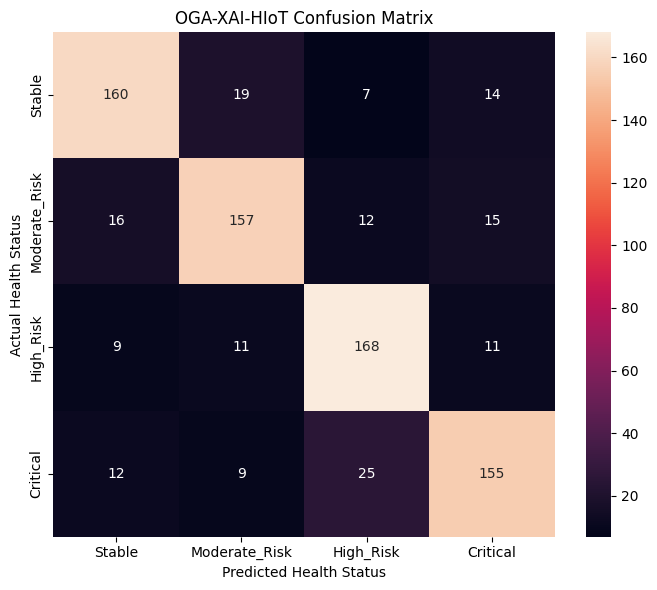

In [ ]:
#@title confusion matrix
cm = confusion_matrix(

    test_targets,

    test_predictions

)


plt.figure(

    figsize=(7, 6)

)


sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    xticklabels=class_names,

    yticklabels=class_names

)


plt.title(

    "OGA-XAI-HIoT Confusion Matrix"

)


plt.xlabel(

    "Predicted Health Status"

)


plt.ylabel(

    "Actual Health Status"

)


plt.tight_layout()


plt.show()

In [ ]:
#@title compare all models
proposed_result = pd.DataFrame({

    "Model": [

        "OGA-XAI-HIoT"

    ],

    "Accuracy": [

        oga_accuracy

    ],

    "Balanced Accuracy": [

        oga_balanced_accuracy

    ],

    "Macro Precision": [

        oga_precision

    ],

    "Macro Recall": [

        oga_recall

    ],

    "Macro F1": [

        oga_f1

    ]

})


display(

    proposed_result

)

,Model,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1
0,OGA-XAI-HIoT,0.8,0.800091,0.800132,0.800091,0.79983


In [ ]:
results_df_cleaned = results_df.rename(columns={
    "Test Accuracy": "Accuracy",
    "Precision": "Macro Precision",
    "Recall": "Macro Recall",
    "F1 Score": "Macro F1"
})
results_df_cleaned["Balanced Accuracy"] = np.nan

advanced_results_cleaned = advanced_results.copy()
advanced_results_cleaned["CV Accuracy"] = np.nan
advanced_results_cleaned["Balanced Accuracy"] = np.nan

final_comparison = pd.concat(
    [
        results_df_cleaned,
        advanced_results_cleaned,
        proposed_result
    ],
    ignore_index=True
)

# Reorder columns for better readability
final_comparison = final_comparison[[
    "Model",
    "CV Accuracy",
    "Accuracy",
    "Balanced Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1"
]]

display(
    final_comparison
)

,Model,CV Accuracy,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1
0,Support Vector Machine,0.810625,0.80000,NaN,0.801097,0.800135,0.799448
1,Random Forest,0.804063,0.79125,NaN,0.791272,0.791341,0.791142
2,K-Nearest Neighbor,0.739688,0.73375,NaN,0.735870,0.733971,0.732338
3,Logistic Regression,0.699375,0.67250,NaN,0.671236,0.672608,0.671683
4,Decision Tree,0.648438,0.64500,NaN,0.645486,0.645020,0.645012
5,Naive Bayes,0.640625,0.60250,NaN,0.603779,0.602582,0.601360
6,TabNet,NaN,0.80625,NaN,0.806731,0.806335,0.805929
7,FT-Transformer,NaN,0.79125,NaN,0.791224,0.791329,0.791266
8,OGA-XAI-HIoT,NaN,0.80000,0.800091,0.800132,0.800091,0.799830


In [ ]:

final_comparison.to_csv(

    "Step12_OGA_XAI_HIoT_Results.csv",

    index=False

)


print(

    "Step 12 results saved successfully."

)

Step 12 results saved successfully.


In [ ]:
#@title Step-13 (Tune hyperparameters)
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from torch.utils.data import DataLoader

from sklearn.metrics import (
    f1_score,
    recall_score,
    accuracy_score,
    balanced_accuracy_score
)

import itertools
import copy

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
#@title Define Hyperparameter Search Space
param_grid = {

    # --------------------------------------------------------
    # Model Architecture Parameters
    # --------------------------------------------------------

    "embedding_dim": [

        16,

        32,

        64

    ],


    "num_heads": [

        2,

        4

    ],


    "num_layers": [

        1,

        2

    ],


    "dropout": [

        0.1,

        0.2,

        0.3

    ],


    # --------------------------------------------------------
    # Training Parameters
    # --------------------------------------------------------

    "learning_rate": [

        1e-3,

        5e-4,

        1e-4

    ],


    "batch_size": [

        16,

        32,

        64

    ],


    "weight_decay": [

        1e-4,

        1e-5

    ],


    # --------------------------------------------------------
    # Ordinal Loss Parameter
    # --------------------------------------------------------

    "ordinal_weight": [

        0.05,

        0.1,

        0.2

    ]

}


print(

    "Hyperparameter search space created successfully."

)


print(

    "\nHyperparameters to be tuned:"

)


for parameter, values in param_grid.items():

    print(

        f"{parameter}: {values}"

    )

Hyperparameter search space created successfully.

Hyperparameters to be tuned:
embedding_dim: [16, 32, 64]
num_heads: [2, 4]
num_layers: [1, 2]
dropout: [0.1, 0.2, 0.3]
learning_rate: [0.001, 0.0005, 0.0001]
batch_size: [16, 32, 64]
weight_decay: [0.0001, 1e-05]
ordinal_weight: [0.05, 0.1, 0.2]


In [156]:
#@title Generate valid hyperparameter configurations
import random

# Number of configurations to test
NUM_CONFIGURATIONS = 20

# Reproducibility
random.seed(42)
np.random.seed(42)


hyperparameter_configs = []


while len(hyperparameter_configs) < NUM_CONFIGURATIONS:

    config = {

        # Model architecture
        "embedding_dim": random.choice(
            param_grid["embedding_dim"]
        ),

        "num_heads": random.choice(
            param_grid["num_heads"]
        ),

        "num_layers": random.choice(
            param_grid["num_layers"]
        ),

        "dropout": random.choice(
            param_grid["dropout"]
        ),

        # Training parameters
        "learning_rate": random.choice(
            param_grid["learning_rate"]
        ),

        "batch_size": random.choice(
            param_grid["batch_size"]
        ),

        "weight_decay": random.choice(
            param_grid["weight_decay"]
        ),

        # Ordinal loss parameter
        "ordinal_weight": random.choice(
            param_grid["ordinal_weight"]
        )
    }


    # --------------------------------------------------------
    # Check if embedding dimension is divisible
    # by number of attention heads
    # --------------------------------------------------------

    if (

        config["embedding_dim"]

        %

        config["num_heads"]

        != 0

    ):

        continue


    # --------------------------------------------------------
    # Avoid duplicate configurations
    # --------------------------------------------------------

    if config not in hyperparameter_configs:

        hyperparameter_configs.append(

            config

        )


print(

    "Generated",

    len(hyperparameter_configs),

    "valid hyperparameter configurations."

)

Generated 20 valid hyperparameter configurations.


In [157]:
#@title Display the configurations
config_df = pd.DataFrame(

    hyperparameter_configs

)


display(

    config_df

)

,embedding_dim,num_heads,num_layers,dropout,learning_rate,batch_size,weight_decay,ordinal_weight
0,64,2,1,0.3,0.0005,16,0.00010,0.05
1,16,2,1,0.3,0.0010,64,0.00001,0.05
2,32,4,1,0.1,0.0001,32,0.00001,0.10
3,16,2,2,0.1,0.0010,32,0.00010,0.10
4,32,4,1,0.3,0.0005,64,0.00010,0.10
5,16,4,2,0.3,0.0010,64,0.00010,0.05
6,64,2,2,0.1,0.0010,16,0.00001,0.10
7,32,4,1,0.2,0.0005,16,0.00001,0.20
8,64,2,1,0.3,0.0001,16,0.00010,0.10
9,32,4,1,0.3,0.0005,16,0.00010,0.05


In [158]:
#@title DataLoader creation
from torch.utils.data import DataLoader


def create_tuning_dataloaders(

    batch_size

):

    tuning_train_loader = DataLoader(

        train_loader.dataset,

        batch_size=batch_size,

        shuffle=True

    )


    tuning_val_loader = DataLoader(

        val_loader.dataset,

        batch_size=batch_size,

        shuffle=False

    )


    return (

        tuning_train_loader,

        tuning_val_loader

    )


print(

    "Tuning DataLoader function created successfully."

)

Tuning DataLoader function created successfully.


In [159]:
#@title Defining training and validation function
import copy


def train_one_configuration(

    config,

    num_epochs=50,

    patience=8

):

    # ========================================================
    # CREATE MODEL
    # ========================================================

    tuning_model = OGA_XAI_HIoT(

        group_input_dims=

            group_input_dims,

        embedding_dim=

            config["embedding_dim"],

        num_heads=

            config["num_heads"],

        num_layers=

            config["num_layers"],

        dropout=

            config["dropout"],

        num_classes=

            NUM_CLASSES

    ).to(

        device

    )


    # ========================================================
    # CREATE DATALOADERS
    # ========================================================

    tuning_train_loader, tuning_val_loader = (

        create_tuning_dataloaders(

            config["batch_size"]

        )

    )


    # ========================================================
    # CREATE OPTIMIZER
    # ========================================================

    tuning_optimizer = torch.optim.AdamW(

        tuning_model.parameters(),

        lr=

            config["learning_rate"],

        weight_decay=

            config["weight_decay"]

    )


    # ========================================================
    # INITIALIZE TRACKING VARIABLES
    # ========================================================

    best_val_f1 = -np.inf

    best_val_loss = np.inf

    patience_counter = 0

    best_model_state = None

    best_epoch = 0


    # ========================================================
    # TRAINING LOOP
    # ========================================================

    for epoch in range(

        num_epochs

    ):

        # ----------------------------------------------------
        # TRAIN
        # ----------------------------------------------------

        tuning_model.train()


        total_train_loss = 0


        for batch_groups, batch_y in (

            tuning_train_loader

        ):

            # Move feature groups to device

            batch_groups = {

                key:

                value.to(

                    device

                )

                for key, value

                in batch_groups.items()

            }


            # Move target to device

            batch_y = batch_y.to(

                device

            )


            # Clear gradients

            tuning_optimizer.zero_grad()


            # Forward pass

            logits, attention_weights = (

                tuning_model(

                    batch_groups

                )

            )


            # Calculate loss
            # IMPORTANT:
            # Use the current configuration's
            # ordinal_weight

            loss, ce_loss, ord_loss = (

                oga_loss(

                    logits,

                    batch_y,

                    config[
                        "ordinal_weight"
                    ]

                )

            )


            # Backpropagation

            loss.backward()


            # Update model parameters

            tuning_optimizer.step()


            total_train_loss += (

                loss.item()

            )


        # ----------------------------------------------------
        # VALIDATION
        # ----------------------------------------------------

        tuning_model.eval()


        total_val_loss = 0


        val_predictions = []

        val_targets = []


        with torch.no_grad():

            for batch_groups, batch_y in (

                tuning_val_loader

            ):

                # Move feature groups to device

                batch_groups = {

                    key:

                    value.to(

                        device

                    )

                    for key, value

                    in batch_groups.items()

                }


                # Move targets to device

                batch_y = batch_y.to(

                    device

                )


                # Forward pass

                logits, attention_weights = (

                    tuning_model(

                        batch_groups

                    )

                )


                # Validation loss

                loss, _, _ = (

                    oga_loss(

                        logits,

                        batch_y,

                        config[
                            "ordinal_weight"
                        ]

                    )

                )


                total_val_loss += (

                    loss.item()

                )


                # Predicted class

                predictions = torch.argmax(

                    logits,

                    dim=1

                )


                # Store predictions

                val_predictions.extend(

                    predictions.cpu().numpy()

                )


                # Store actual labels

                val_targets.extend(

                    batch_y.cpu().numpy()

                )


        # ----------------------------------------------------
        # CALCULATE AVERAGE LOSSES
        # ----------------------------------------------------

        train_loss = (

            total_train_loss /

            len(

                tuning_train_loader

            )

        )


        val_loss = (

            total_val_loss /

            len(

                tuning_val_loader

            )

        )


        # ----------------------------------------------------
        # CALCULATE VALIDATION MACRO F1
        # ----------------------------------------------------

        val_f1 = f1_score(

            val_targets,

            val_predictions,

            average="macro",

            zero_division=0

        )


        # ----------------------------------------------------
        # PRINT CURRENT EPOCH
        # ----------------------------------------------------

        print(

            f"Epoch {epoch + 1:03d} | "

            f"Train Loss: {train_loss:.4f} | "

            f"Val Loss: {val_loss:.4f} | "

            f"Val Macro F1: {val_f1:.4f}"

        )


        # ----------------------------------------------------
        # EARLY STOPPING
        # ----------------------------------------------------

        if val_f1 > best_val_f1:

            best_val_f1 = val_f1

            best_val_loss = val_loss

            best_epoch = epoch + 1

            patience_counter = 0


            # Save best model parameters

            best_model_state = {

                key:

                value.cpu().clone()

                for key, value

                in tuning_model.state_dict().items()

            }


        else:

            patience_counter += 1


        # ----------------------------------------------------
        # STOP IF NO IMPROVEMENT
        # ----------------------------------------------------

        if patience_counter >= patience:

            print(

                "Early stopping triggered."

            )

            break


    # ========================================================
    # RETURN RESULTS
    # ========================================================

    return {

        "config":

            config,

        "best_val_f1":

            best_val_f1,

        "best_val_loss":

            best_val_loss,

        "best_epoch":

            best_epoch,

        "best_model_state":

            best_model_state

    }

In [160]:
#@title Run hyperparameter tuning
all_tuning_results = []


best_tuning_result = None


best_macro_f1 = -np.inf


for i, config in enumerate(

    hyperparameter_configs,

    start=1

):

    print(

        "\n"

        + "=" * 80

    )

    print(

        f"CONFIGURATION {i} "

        f"OF {len(hyperparameter_configs)}"

    )

    print(

        "=" * 80

    )


    print(

        "Current configuration:"

    )


    for parameter, value in config.items():

        print(

            f"{parameter}: {value}"

        )


    # --------------------------------------------------------
    # Train current configuration
    # --------------------------------------------------------

    result = train_one_configuration(

        config=config,

        num_epochs=50,

        patience=8

    )


    # --------------------------------------------------------
    # Store result
    # --------------------------------------------------------

    result_row = {

        **config,

        "best_val_macro_f1":

            result[
                "best_val_f1"
            ],

        "best_val_loss":

            result[
                "best_val_loss"
            ],

        "best_epoch":

            result[
                "best_epoch"
            ]

    }


    all_tuning_results.append(

        result_row

    )


    # --------------------------------------------------------
    # Check whether this is the best configuration
    # --------------------------------------------------------

    if (

        result[
            "best_val_f1"
        ]

        >

        best_macro_f1

    ):

        best_macro_f1 = (

            result[
                "best_val_f1"
            ]

        )


        best_tuning_result = (

            result

        )


        print(

            "\nNew best configuration found!"

        )


    print(

        "\nCurrent best Validation Macro F1:",

        f"{best_macro_f1:.4f}"

    )


print(

    "\n"

    + "=" * 80

)

print(

    "HYPERPARAMETER TUNING COMPLETED"

)

print(

    "=" * 80

)


CONFIGURATION 1 OF 20
Current configuration:
embedding_dim: 64
num_heads: 2
num_layers: 1
dropout: 0.3
learning_rate: 0.0005
batch_size: 16
weight_decay: 0.0001
ordinal_weight: 0.05


/tmp/ipykernel_531/43325996.py:58: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  nn.TransformerEncoder(


Epoch 001 | Train Loss: 1.1605 | Val Loss: 0.7946 | Val Macro F1: 0.6950
Epoch 002 | Train Loss: 0.8833 | Val Loss: 0.7347 | Val Macro F1: 0.7236
Epoch 003 | Train Loss: 0.8292 | Val Loss: 0.7156 | Val Macro F1: 0.7255
Epoch 004 | Train Loss: 0.7982 | Val Loss: 0.6875 | Val Macro F1: 0.7472
Epoch 005 | Train Loss: 0.7654 | Val Loss: 0.6702 | Val Macro F1: 0.7522
Epoch 006 | Train Loss: 0.7405 | Val Loss: 0.6736 | Val Macro F1: 0.7606
Epoch 007 | Train Loss: 0.7252 | Val Loss: 0.6325 | Val Macro F1: 0.7795
Epoch 008 | Train Loss: 0.7115 | Val Loss: 0.6234 | Val Macro F1: 0.7723
Epoch 009 | Train Loss: 0.6863 | Val Loss: 0.6099 | Val Macro F1: 0.7803
Epoch 010 | Train Loss: 0.6687 | Val Loss: 0.5862 | Val Macro F1: 0.8018
Epoch 011 | Train Loss: 0.6622 | Val Loss: 0.6454 | Val Macro F1: 0.7752
Epoch 012 | Train Loss: 0.6708 | Val Loss: 0.5882 | Val Macro F1: 0.8082
Epoch 013 | Train Loss: 0.6386 | Val Loss: 0.6078 | Val Macro F1: 0.7858
Epoch 014 | Train Loss: 0.6302 | Val Loss: 0.5884 |

/tmp/ipykernel_531/43325996.py:58: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  nn.TransformerEncoder(


Epoch 001 | Train Loss: 1.3943 | Val Loss: 1.3087 | Val Macro F1: 0.5842
Epoch 002 | Train Loss: 1.2822 | Val Loss: 1.0999 | Val Macro F1: 0.6389
Epoch 003 | Train Loss: 1.1370 | Val Loss: 0.9491 | Val Macro F1: 0.6547
Epoch 004 | Train Loss: 1.0747 | Val Loss: 0.8752 | Val Macro F1: 0.6874
Epoch 005 | Train Loss: 1.0303 | Val Loss: 0.8278 | Val Macro F1: 0.7075
Epoch 006 | Train Loss: 0.9898 | Val Loss: 0.8082 | Val Macro F1: 0.6977
Epoch 007 | Train Loss: 0.9525 | Val Loss: 0.7894 | Val Macro F1: 0.7009
Epoch 008 | Train Loss: 0.9368 | Val Loss: 0.7718 | Val Macro F1: 0.7078
Epoch 009 | Train Loss: 0.9238 | Val Loss: 0.7670 | Val Macro F1: 0.7095
Epoch 010 | Train Loss: 0.9150 | Val Loss: 0.7702 | Val Macro F1: 0.7205
Epoch 011 | Train Loss: 0.8962 | Val Loss: 0.7491 | Val Macro F1: 0.7109
Epoch 012 | Train Loss: 0.8983 | Val Loss: 0.7570 | Val Macro F1: 0.7199
Epoch 013 | Train Loss: 0.8943 | Val Loss: 0.7513 | Val Macro F1: 0.7244
Epoch 014 | Train Loss: 0.8737 | Val Loss: 0.7404 |

...

Epoch 001 | Train Loss: 1.4822 | Val Loss: 1.3040 | Val Macro F1: 0.6363
Epoch 002 | Train Loss: 1.2111 | Val Loss: 0.9872 | Val Macro F1: 0.6861
Epoch 003 | Train Loss: 1.0372 | Val Loss: 0.8807 | Val Macro F1: 0.7014
Epoch 004 | Train Loss: 0.9672 | Val Loss: 0.8373 | Val Macro F1: 0.7130
Epoch 005 | Train Loss: 0.9325 | Val Loss: 0.8159 | Val Macro F1: 0.7275
Epoch 006 | Train Loss: 0.9039 | Val Loss: 0.7890 | Val Macro F1: 0.7416
Epoch 007 | Train Loss: 0.8827 | Val Loss: 0.7843 | Val Macro F1: 0.7297
Epoch 008 | Train Loss: 0.8676 | Val Loss: 0.7604 | Val Macro F1: 0.7424
Epoch 009 | Train Loss: 0.8549 | Val Loss: 0.7438 | Val Macro F1: 0.7471
Epoch 010 | Train Loss: 0.8341 | Val Loss: 0.7244 | Val Macro F1: 0.7658
Epoch 011 | Train Loss: 0.8154 | Val Loss: 0.7228 | Val Macro F1: 0.7652
Epoch 012 | Train Loss: 0.7971 | Val Loss: 0.7083 | Val Macro F1: 0.7641
Epoch 013 | Train Loss: 0.7868 | Val Loss: 0.7051 | Val Macro F1: 0.7639
Epoch 014 | Train Loss: 0.7696 | Val Loss: 0.7024 |

/tmp/ipykernel_531/43325996.py:58: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  nn.TransformerEncoder(


Epoch 001 | Train Loss: 1.3161 | Val Loss: 1.0737 | Val Macro F1: 0.6482
Epoch 002 | Train Loss: 0.9869 | Val Loss: 0.7959 | Val Macro F1: 0.7181
Epoch 003 | Train Loss: 0.8619 | Val Loss: 0.7391 | Val Macro F1: 0.7253
Epoch 004 | Train Loss: 0.7979 | Val Loss: 0.7158 | Val Macro F1: 0.7389
Epoch 005 | Train Loss: 0.7695 | Val Loss: 0.6932 | Val Macro F1: 0.7521
Epoch 006 | Train Loss: 0.7225 | Val Loss: 0.6560 | Val Macro F1: 0.7640
Epoch 007 | Train Loss: 0.7015 | Val Loss: 0.6371 | Val Macro F1: 0.7701
Epoch 008 | Train Loss: 0.6852 | Val Loss: 0.6368 | Val Macro F1: 0.7771
Epoch 009 | Train Loss: 0.6481 | Val Loss: 0.6216 | Val Macro F1: 0.7797
Epoch 010 | Train Loss: 0.6285 | Val Loss: 0.5974 | Val Macro F1: 0.7926
Epoch 011 | Train Loss: 0.6082 | Val Loss: 0.5814 | Val Macro F1: 0.7989
Epoch 012 | Train Loss: 0.5929 | Val Loss: 0.5655 | Val Macro F1: 0.7970
Epoch 013 | Train Loss: 0.5779 | Val Loss: 0.5663 | Val Macro F1: 0.8048
Epoch 014 | Train Loss: 0.5635 | Val Loss: 0.5555 |

/tmp/ipykernel_531/43325996.py:58: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  nn.TransformerEncoder(


Epoch 001 | Train Loss: 1.4149 | Val Loss: 1.3230 | Val Macro F1: 0.5141
Epoch 002 | Train Loss: 1.2908 | Val Loss: 1.1592 | Val Macro F1: 0.5549
Epoch 003 | Train Loss: 1.1801 | Val Loss: 1.0154 | Val Macro F1: 0.6633
Epoch 004 | Train Loss: 1.0742 | Val Loss: 0.8623 | Val Macro F1: 0.7048
Epoch 005 | Train Loss: 1.0117 | Val Loss: 0.8131 | Val Macro F1: 0.7066
Epoch 006 | Train Loss: 0.9446 | Val Loss: 0.7682 | Val Macro F1: 0.7063
Epoch 007 | Train Loss: 0.9487 | Val Loss: 0.7574 | Val Macro F1: 0.7166
Epoch 008 | Train Loss: 0.9246 | Val Loss: 0.7414 | Val Macro F1: 0.7194
Epoch 009 | Train Loss: 0.8993 | Val Loss: 0.7402 | Val Macro F1: 0.7218
Epoch 010 | Train Loss: 0.8965 | Val Loss: 0.7295 | Val Macro F1: 0.7276
Epoch 011 | Train Loss: 0.8762 | Val Loss: 0.7159 | Val Macro F1: 0.7332
Epoch 012 | Train Loss: 0.8644 | Val Loss: 0.7084 | Val Macro F1: 0.7342
Epoch 013 | Train Loss: 0.8589 | Val Loss: 0.7100 | Val Macro F1: 0.7299
Epoch 014 | Train Loss: 0.8559 | Val Loss: 0.7025 |

In [161]:
#@title Display all tuning
tuning_results_df = pd.DataFrame(

    all_tuning_results

)


# Sort by Validation Macro F1

tuning_results_df = (

    tuning_results_df

    .sort_values(

        by="best_val_macro_f1",

        ascending=False

    )

    .reset_index(

        drop=True

    )

)


display(

    tuning_results_df

)

,embedding_dim,num_heads,num_layers,dropout,learning_rate,batch_size,weight_decay,ordinal_weight,best_val_macro_f1,best_val_loss,best_epoch
0,32,4,1,0.1,0.0005,32,0.00010,0.05,0.855006,0.472436,35
1,32,4,2,0.1,0.0010,64,0.00001,0.05,0.845936,0.504198,20
2,32,4,1,0.3,0.0005,16,0.00010,0.05,0.842377,0.489015,43
3,32,4,1,0.2,0.0005,16,0.00001,0.20,0.837192,0.569670,31
4,64,4,2,0.3,0.0005,16,0.00001,0.05,0.837106,0.540980,32
5,64,2,1,0.3,0.0005,16,0.00010,0.05,0.830281,0.539562,18
6,16,4,1,0.1,0.0005,16,0.00010,0.20,0.823371,0.574388,47
7,64,2,1,0.3,0.0001,16,0.00010,0.10,0.822056,0.575776,50
8,32,4,1,0.3,0.0005,64,0.00010,0.10,0.820575,0.571020,42
9,64,4,1,0.1,0.0010,16,0.00010,0.20,0.817812,0.613417,11


In [162]:
#@title Display the best hyperparameters
best_config = (

    best_tuning_result[

        "config"

    ]

)


print(

    "=" * 60

)

print(

    "BEST OGA-XAI-HIoT HYPERPARAMETERS"

)

print(

    "=" * 60

)


for parameter, value in best_config.items():

    print(

        f"{parameter}: {value}"

    )


print(

    "\nBest Validation Macro F1:",

    f"{best_tuning_result['best_val_f1']:.4f}"

)


print(

    "Best Validation Loss:",

    f"{best_tuning_result['best_val_loss']:.4f}"

)


print(

    "Best Epoch:",

    best_tuning_result["best_epoch"]

)

BEST OGA-XAI-HIoT HYPERPARAMETERS
embedding_dim: 32
num_heads: 4
num_layers: 1
dropout: 0.1
learning_rate: 0.0005
batch_size: 32
weight_decay: 0.0001
ordinal_weight: 0.05

Best Validation Macro F1: 0.8550
Best Validation Loss: 0.4724
Best Epoch: 35


In [163]:
#@title Restore the best tuned model
best_model = OGA_XAI_HIoT(

    group_input_dims=

        group_input_dims,

    embedding_dim=

        best_config[
            "embedding_dim"
        ],

    num_heads=

        best_config[
            "num_heads"
        ],

    num_layers=

        best_config[
            "num_layers"
        ],

    dropout=

        best_config[
            "dropout"
        ],

    num_classes=

        NUM_CLASSES

).to(

    device

)


# Load the best learned parameters

best_model.load_state_dict(

    best_tuning_result[

        "best_model_state"

    ]

)


# Set model to evaluation mode

best_model.eval()


print(

    "Best tuned OGA-XAI-HIoT model restored successfully."

)

Best tuned OGA-XAI-HIoT model restored successfully.


/tmp/ipykernel_531/43325996.py:58: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  nn.TransformerEncoder(


In [165]:
#@title Step 13 - Cell 11: Save Hyperparameter Tuning Results

tuning_results_df.to_csv(

    "Step13_Hyperparameter_Tuning_Results.csv",

    index=False

)


# Save best configuration

best_config_df = pd.DataFrame({

    "Hyperparameter":

        list(

            best_config.keys()

        ),

    "Best_Value":

        list(

            best_config.values()

        )

})


best_config_df.to_csv(

    "Step13_Best_Hyperparameters.csv",

    index=False

)


print(

    "Step 13 results saved successfully."

)

Step 13 results saved successfully.


In [166]:
#@title Step-14(Prevention of Overfitting)
import random
import numpy as np
import torch
import copy

from sklearn.metrics import (
    f1_score,
    recall_score
)

print("Step 14 libraries imported successfully.")

Step 14 libraries imported successfully.


In [167]:
#@title Repeat Random Seeds
random_seeds = [

    42,

    123,

    2024,

    777,

    999

]


print(

    "Random seeds used for repeated experiments:"

)


for seed in random_seeds:

    print(

        seed

    )

Random seeds used for repeated experiments:
42
123
2024
777
999


In [168]:
#@title Set Random Seed Function

def set_random_seed(

    seed

):

    random.seed(

        seed

    )


    np.random.seed(

        seed

    )


    torch.manual_seed(

        seed

    )


    if torch.cuda.is_available():

        torch.cuda.manual_seed(

            seed

        )

        torch.cuda.manual_seed_all(

            seed

        )


    # Make CUDA operations reproducible

    torch.backends.cudnn.deterministic = True

    torch.backends.cudnn.benchmark = False


print(

    "Random seed function created successfully."

)

Random seed function created successfully.


In [169]:
#@title Use Best Hyperparameters

print(

    "Best hyperparameters selected in Step 13:"

)


for parameter, value in best_config.items():

    print(

        f"{parameter}: {value}"

    )

Best hyperparameters selected in Step 13:
embedding_dim: 32
num_heads: 4
num_layers: 1
dropout: 0.1
learning_rate: 0.0005
batch_size: 32
weight_decay: 0.0001
ordinal_weight: 0.05


In [170]:
#@title Create DataLoaders

from torch.utils.data import DataLoader


def create_seed_dataloaders(

    batch_size,

    seed

):

    # --------------------------------------------------------
    # Create a generator for reproducible shuffling
    # --------------------------------------------------------

    generator = torch.Generator()


    generator.manual_seed(

        seed

    )


    # --------------------------------------------------------
    # Training DataLoader
    # --------------------------------------------------------

    seed_train_loader = DataLoader(

        train_loader.dataset,

        batch_size=batch_size,

        shuffle=True,

        generator=generator

    )


    # --------------------------------------------------------
    # Validation DataLoader
    # --------------------------------------------------------

    seed_val_loader = DataLoader(

        val_loader.dataset,

        batch_size=batch_size,

        shuffle=False

    )


    return (

        seed_train_loader,

        seed_val_loader

    )


print(

    "Seed-specific DataLoader function created successfully."

)

Seed-specific DataLoader function created successfully.
